# LC Improvement Training

This notebook follows the same shape as `experiment.ipynb`, but trains LC as an improvement policy. The model starts from existing LC routes in `examples/nx_heuristic_results_10r_2_12`, revisits every route, and learns typed actions: extend, trim start, trim end, halt.

## 1. Global Setup & Paths

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
import importlib
import sys
from pathlib import Path

import torch
from hydra import compose, initialize_config_dir

ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "pyproject.toml").exists():
    ROOT_DIR = ROOT_DIR.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from connectpt.routes_generator import utils as lrnu
from connectpt.routes_generator.citygraph_dataset import STOP_KEY
from connectpt.routes_generator import improvement_learning as il

il = importlib.reload(il)

from connectpt.routes_generator.improvement_learning import (
    evaluate_lc_improvement,
    load_raw_graphs_and_lc_routes,
    make_improvement_batch,
    rollout_lc_improvement,
    summarize_route_action_stats,
    train_lc_improvement_cfg,
)

CFG_DIR = ROOT_DIR / "connectpt" / "routes_generator" / "cfg"
RAW_GRAPHS_PATH = ROOT_DIR / "examples" / "data" / "raw_graphs_1000.pkl"
LC_RESULTS_DIR = ROOT_DIR / "examples" / "nx_heuristic_results_10r_len12"
OUTPUT_DIR = ROOT_DIR / "examples" / "route_generator" / "lc_improvement_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Config dir: {CFG_DIR}")
print(f"Graphs:     {RAW_GRAPHS_PATH}")
print(f"LC routes:  {LC_RESULTS_DIR}")
print(f"Output:     {OUTPUT_DIR}")

Config dir: d:\PythonProjects\connectpt\connectpt\routes_generator\cfg
Graphs:     d:\PythonProjects\connectpt\examples\data\raw_graphs_1000.pkl
LC routes:  d:\PythonProjects\connectpt\examples\nx_heuristic_results_10r_len12
Output:     d:\PythonProjects\connectpt\examples\route_generator\lc_improvement_outputs


## 2. Load Graphs And Existing LC Routes

In [3]:
graphs, seed_routes = load_raw_graphs_and_lc_routes(RAW_GRAPHS_PATH, LC_RESULTS_DIR)
N_GRAPHS, N_ROUTES, SEED_ROUTE_LEN = seed_routes.shape

print(f"Loaded graphs: {len(graphs)}")
print(f"Routes shape:  {tuple(seed_routes.shape)}")
print(seed_routes[0])

Loaded graphs: 1000
Routes shape:  (1000, 10, 12)
tensor([[15, 25, 35, 36, 37, 27, 17,  7,  6,  5,  4, 14],
        [45, 44, 43, 33, 34, 24, 23, 22, 21, 20, 30, 40],
        [45, 44, 43, 33, 34, 24, 14,  4,  3,  2,  1,  0],
        [ 5,  6, 16, 15, 14,  4,  3,  2,  1,  0, 10, 11],
        [40, 30, 20, 21, 22, 12, 11, 10,  0,  1,  2,  3],
        [36, 26, 16,  6,  5,  4,  3,  2,  1,  0, 10, 11],
        [25, 15, 16, 26, 36, 37, 27, 28, 18, 19,  9,  8],
        [ 6,  5,  4,  3,  2,  1,  0, 10, 11, 12, 13, 14],
        [49, 48, 38, 28, 27, 17,  7,  8, 18, 19, 29, 39],
        [ 3,  4,  5,  6, 16, 26, 36, 35, 34, 33, 43, 44]])


## 3. LC Route File Statistics

In [4]:
import pickle
from collections import Counter


def as_route_set(raw_routes):
    if isinstance(raw_routes, list):
        raw_routes = raw_routes[0]
    if getattr(raw_routes, "ndim", 0) == 3 and raw_routes.shape[0] == 1:
        raw_routes = raw_routes.squeeze(0)
    if not torch.is_tensor(raw_routes):
        raw_routes = torch.as_tensor(raw_routes)
    if raw_routes.ndim == 1:
        raw_routes = raw_routes.unsqueeze(0)
    return raw_routes


def describe_values(values):
    if not values:
        return "no values"
    tensor = torch.tensor(values, dtype=torch.float32)
    return (
        f"count={tensor.numel()}, "
        f"min={tensor.min().item():.0f}, "
        f"median={tensor.median().item():.0f}, "
        f"mean={tensor.mean().item():.2f}, "
        f"max={tensor.max().item():.0f}"
    )


route_files = sorted(LC_RESULTS_DIR.glob("graph_*/lc_*_routes_routes.pkl"))
route_counts = []
route_lengths = []
file_rows = []


graph_node_counts = []
graph_edge_counts = []
for graph in graphs:
    stop_data = graph[STOP_KEY]
    graph_node_counts.append(int(stop_data.num_nodes))
    if hasattr(stop_data, "edge_index") and stop_data.edge_index is not None:
        graph_edge_counts.append(int(stop_data.edge_index.shape[1]))
    elif hasattr(graph, "street_adj"):
        graph_edge_counts.append(int((graph.street_adj > 0).sum().item()))


for route_path in route_files:
    with route_path.open("rb") as file:
        routes = as_route_set(pickle.load(file))

    lengths = (routes >= 0).sum(dim=1).tolist()
    lengths = [int(length) for length in lengths]
    route_counts.append(int(routes.shape[0]))
    route_lengths.extend(lengths)

    file_rows.append(
        {
            "file": route_path.relative_to(LC_RESULTS_DIR),
            "routes": int(routes.shape[0]),
            "min_len": min(lengths) if lengths else 0,
            "mean_len": sum(lengths) / len(lengths) if lengths else 0,
            "max_len": max(lengths) if lengths else 0,
        }
    )

print(f"Route files:  {len(route_files)}")
print(f"Total routes: {sum(route_counts)}")
print(f"Routes/file:  {describe_values(route_counts)}")
print(f"Route length: {describe_values(route_lengths)}")
print(f"Graph nodes:  {describe_values(graph_node_counts)}")
if graph_edge_counts:
    print(f"Graph edges:  {describe_values(graph_edge_counts)}")

print("\nGraph node count distribution:")
for n_nodes, n_graphs_with_size in sorted(Counter(graph_node_counts).items()):
    print(f"  {n_nodes} nodes: {n_graphs_with_size} graphs")

print("\nRoutes per file distribution:")
for n_routes, n_files in sorted(Counter(route_counts).items()):
    print(f"  {n_routes} routes: {n_files} files")

print("\nRoute length distribution:")
for route_len, n_routes in sorted(Counter(route_lengths).items()):
    print(f"  length {route_len}: {n_routes} routes")

print("\nFirst 10 files:")
for row in file_rows[:10]:
    print(
        f"  {row['file']}: routes={row['routes']}, "
        f"len min/mean/max={row['min_len']}/{row['mean_len']:.2f}/{row['max_len']}"
    )

Route files:  1000
Total routes: 10000
Routes/file:  count=1000, min=10, median=10, mean=10.00, max=10
Route length: count=10000, min=12, median=12, mean=12.00, max=12
Graph nodes:  count=1000, min=50, median=50, mean=50.00, max=50
Graph edges:  count=1000, min=2450, median=2450, mean=2450.00, max=2450

Graph node count distribution:
  50 nodes: 1000 graphs

Routes per file distribution:
  10 routes: 1000 files

Route length distribution:
  length 12: 10000 routes

First 10 files:
  graph_0000\lc_nx_heuristic_graph_0000_routes_routes.pkl: routes=10, len min/mean/max=12/12.00/12
  graph_0001\lc_nx_heuristic_graph_0001_routes_routes.pkl: routes=10, len min/mean/max=12/12.00/12
  graph_0002\lc_nx_heuristic_graph_0002_routes_routes.pkl: routes=10, len min/mean/max=12/12.00/12
  graph_0003\lc_nx_heuristic_graph_0003_routes_routes.pkl: routes=10, len min/mean/max=12/12.00/12
  graph_0004\lc_nx_heuristic_graph_0004_routes_routes.pkl: routes=10, len min/mean/max=12/12.00/12
  graph_0005\lc_nx_

## 4. Visualize One Training Graph

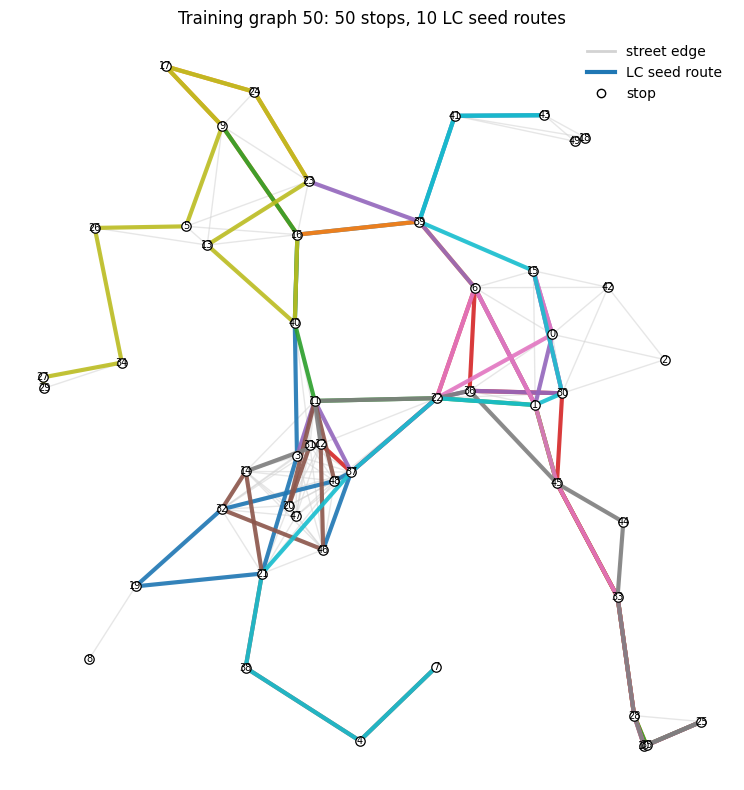

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

from connectpt.routes_generator.citygraph_dataset import STOP_KEY

GRAPH_IDX = 50
graph = graphs[GRAPH_IDX]
routes = seed_routes[GRAPH_IDX]

coords = graph[STOP_KEY].pos.detach().cpu().numpy()
street_adj = graph.street_adj.detach().cpu().numpy()
n_nodes = coords.shape[0]

fig, ax = plt.subplots(figsize=(8, 8))

for i in range(n_nodes):
    for j in range(i + 1, n_nodes):
        if np.isfinite(street_adj[i, j]) or np.isfinite(street_adj[j, i]):
            ax.plot(
                [coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                color="lightgray",
                linewidth=1.0,
                alpha=0.55,
                zorder=1,
            )

route_colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(routes))))
for route_idx, route_tensor in enumerate(routes):
    route = [int(node) for node in route_tensor.detach().cpu().tolist()]
    route = [node for node in route if 0 <= node < n_nodes]
    if len(route) < 2:
        continue

    color = route_colors[route_idx % len(route_colors)]
    for start, end in zip(route[:-1], route[1:]):
        ax.plot(
            [coords[start, 0], coords[end, 0]],
            [coords[start, 1], coords[end, 1]],
            color=color,
            linewidth=3.0,
            alpha=0.9,
            solid_capstyle="round",
            zorder=3,
        )
    ax.scatter(
        coords[route, 0],
        coords[route, 1],
        color=color,
        s=32,
        edgecolor="white",
        linewidth=0.8,
        zorder=4,
    )

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    s=46,
    facecolor="white",
    edgecolor="black",
    linewidth=0.9,
    zorder=5,
)
for node_idx, (x_coord, y_coord) in enumerate(coords):
    ax.text(
        x_coord,
        y_coord,
        str(node_idx),
        fontsize=7,
        ha="center",
        va="center",
        zorder=6,
    )

legend_items = [
    Line2D([0], [0], color="lightgray", linewidth=2, label="street edge"),
    Line2D([0], [0], color=route_colors[0], linewidth=3, label="LC seed route"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="black",
        markerfacecolor="white",
        linewidth=0,
        label="stop",
    ),
]
ax.legend(handles=legend_items, loc="upper right", frameon=False)
ax.set_title(
    f"Training graph {GRAPH_IDX}: {n_nodes} stops, {len(routes)} LC seed routes"
)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()

## 5. Configure Trim LC Model

In [6]:
import numpy as np
import pandas as pd

MIN_ROUTE_LEN = 2
MAX_ROUTE_LEN = 12
TARGET_N_ROUTES = 10
MAX_ROUTE_EDIT_STEPS = MAX_ROUTE_LEN
BATCH_SIZE = 32  # cfg.batch_size=512 is too large for improvement PPO rollout states
TRAIN_FRACTION = 0.9
SPLIT_SEED = 0
FORCE_NONHALT_FIRST_STEP = False
MAX_ROLLOUT_SAMPLES = 8192  # guard: BATCH_SIZE * PPO_HORIZON must stay below this
SUMMARY_PATH = LC_RESULTS_DIR / "all_results_summary.csv"
SPLIT_STRATIFY_COLUMNS = [
    "n_routes",
    "max_route_len",
    "demand_time_weight",
    "route_time_weight",
    "median_connectivity_weight",
]


def load_lc_route_metadata(summary_path, n_graphs):
    metadata = pd.DataFrame({"graph_index": np.arange(n_graphs, dtype=np.int64)})
    if not summary_path.exists():
        print(f"Summary file not found: {summary_path}; using an unstratified split.")
        return metadata

    summary_df = pd.read_csv(summary_path)
    if "graph_index" not in summary_df.columns:
        raise ValueError(f"Expected graph_index column in {summary_path}")

    summary_df = summary_df.drop_duplicates("graph_index").copy()
    summary_df["graph_index"] = summary_df["graph_index"].astype(int)
    metadata = metadata.merge(summary_df, on="graph_index", how="left")
    return metadata


def make_stratified_split_indices(metadata_df, train_fraction, seed, stratify_columns):
    rng = np.random.default_rng(seed)
    split_df = metadata_df.copy()

    for column in stratify_columns:
        if column not in split_df.columns:
            split_df[column] = "all"

    for column in stratify_columns:
        if pd.api.types.is_numeric_dtype(split_df[column]):
            split_df[column] = split_df[column].fillna(-1)
            if split_df[column].dtype.kind == "f":
                split_df[column] = split_df[column].round(6)
        else:
            split_df[column] = split_df[column].fillna("missing")

    train_indices = []
    val_indices = []
    for _, group_df in split_df.groupby(stratify_columns, dropna=False, sort=True):
        group_indices = group_df["graph_index"].to_numpy(dtype=np.int64, copy=True)
        rng.shuffle(group_indices)

        if len(group_indices) <= 1:
            n_train = len(group_indices)
        else:
            n_train = int(round(train_fraction * len(group_indices)))
            n_train = max(1, min(n_train, len(group_indices) - 1))

        train_indices.extend(group_indices[:n_train].tolist())
        val_indices.extend(group_indices[n_train:].tolist())

    train_indices = np.asarray(train_indices, dtype=np.int64)
    val_indices = np.asarray(val_indices, dtype=np.int64)
    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    return (
        torch.as_tensor(train_indices, dtype=torch.long),
        torch.as_tensor(val_indices, dtype=torch.long),
    )


with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
    cfg = compose(
        # Switch to "d3po_50nodes.yaml" to run D3PO via cfg.trainer.
        config_name="d3po_50nodes.yaml",
        overrides=[
            "model=bestsofar_feb2023_trim",
            "model.route_generator.kwargs.serial_halting=True",
            "++run_name=lc_improvement_trim",
            "++experiment.logdir=null",
        ],
    )

# Tuned for the current LC/nx-heuristic improvement run. The previous
# config used only about 25% of VRAM, so spend the headroom on a larger
# batch/minibatch and gentler PPO updates rather than a longer horizon.
cfg.lr = 3e-4
cfg.decay = 1e-5
cfg.entropy_weight = 1e-4
TRAINER_CFG = cfg.d3po if getattr(cfg, "trainer", "ppo") == "d3po" else cfg.ppo
TRAINER_CFG.n_epochs = 2
TRAINER_CFG.minibatch_size = 256

CFG_BATCH_SIZE = int(cfg.batch_size)
PPO_N_ITERATIONS = int(TRAINER_CFG.n_iterations)
PPO_VAL_PERIOD = int(TRAINER_CFG.val_period)
PPO_HORIZON = int(TRAINER_CFG.horizon)
PPO_EPOCHS = int(TRAINER_CFG.n_epochs)
PPO_MINIBATCH_SIZE = int(TRAINER_CFG.minibatch_size)
MAX_TRIM_ACTIONS_PER_ROUTE = getattr(cfg, "max_trim_actions_per_route", 1)

device, run_name, _, cost_obj, model = lrnu.process_standard_experiment_cfg(
    cfg,
    run_name_prefix="improvement_",
)
cost_obj.ignore_stops_oob = True  # match construction training: ignore route length/unstarted-slot penalty in cost

LC_ROUTE_METADATA = load_lc_route_metadata(SUMMARY_PATH, N_GRAPHS)
TRAIN_INDICES, VAL_INDICES = make_stratified_split_indices(
    LC_ROUTE_METADATA,
    train_fraction=TRAIN_FRACTION,
    seed=SPLIT_SEED,
    stratify_columns=SPLIT_STRATIFY_COLUMNS,
)
BEST_MODEL_PATH = OUTPUT_DIR / f"{run_name}.pt"
VAL_ROUTES_PATH = OUTPUT_DIR / f"{run_name}_val_routes.pt"

split_balance = LC_ROUTE_METADATA.copy()
split_balance["split"] = "val"
split_balance.loc[
    split_balance["graph_index"].isin(TRAIN_INDICES.tolist()),
    "split",
] = "train"

balance_columns = [
    column for column in SPLIT_STRATIFY_COLUMNS
    if column in split_balance.columns
]
if balance_columns:
    balance_df = (
        split_balance
        .groupby(balance_columns + ["split"], dropna=False)
        .size()
        .unstack(fill_value=0)
        .reset_index()
        .sort_values(balance_columns)
        .reset_index(drop=True)
    )
    display(balance_df)

print(f"Device: {device}")
print(f"Run:    {run_name}")
print(f"Trainer: {getattr(cfg, 'trainer', 'ppo')}")
print(f"Model:  {type(model).__name__}")
print(f"Trim actions enabled: {getattr(model, 'supports_trim_actions', False)}")
print(f"Serial halting: {getattr(model, 'serial_halting', None)}")
print(f"Config diff_reward: {cfg.diff_reward}")
print(f"Config batch size: {CFG_BATCH_SIZE}")
print(f"Reward scale: {cfg.reward_scale}")
print(f"Zero trim reward: {bool(getattr(cfg, 'zero_trim_reward', False))}")
print(f"Edit step penalty: {float(getattr(cfg, 'edit_step_penalty', 0.0))}")
print(f"Forced halt penalty: {float(getattr(cfg, 'forced_halt_penalty', 0.0))}")
print(f"Discount rate: {cfg.discount_rate}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Seed routes per graph: {seed_routes.shape[1]}")
print(f"Target route slots: {TARGET_N_ROUTES}")
print(f"Empty route slots: {max(TARGET_N_ROUTES - seed_routes.shape[1], 0) if TARGET_N_ROUTES is not None else 0}")
print(f"PPO iterations: {PPO_N_ITERATIONS}")
print(f"PPO val period: {PPO_VAL_PERIOD}")
print(f"PPO horizon: {PPO_HORIZON}")
print(f"PPO epochs: {PPO_EPOCHS}")
print(f"PPO minibatch size: {PPO_MINIBATCH_SIZE}")
print(f"Max route edit steps: {MAX_ROUTE_EDIT_STEPS}")
print(f"Max trim actions per route: {MAX_TRIM_ACTIONS_PER_ROUTE}")
print(f"Rollout samples: {BATCH_SIZE * PPO_HORIZON} / {MAX_ROLLOUT_SAMPLES}")
print(f"Split stratify columns: {balance_columns}")
print(f"Train graphs: {len(TRAIN_INDICES)}")
print(f"Val graphs:   {len(VAL_INDICES)}")
print(f"Checkpoint:   {BEST_MODEL_PATH}")

split,n_routes,max_route_len,demand_time_weight,route_time_weight,median_connectivity_weight,train,val
0,10,12,0.0,0.0,1.0,300,33
1,10,12,0.0,1.0,0.0,300,33
2,10,12,1.0,0.0,0.0,301,33


Device: cpu
Run:    improvement_lc_improvement_trim
Trainer: d3po
Model:  TrimPathCombiningRouteGenerator
Trim actions enabled: True
Serial halting: True
Config diff_reward: True
Config batch size: 512
Reward scale: 1.0
Zero trim reward: True
Edit step penalty: 0.0
Forced halt penalty: 0.0
Discount rate: 1.0
Batch size: 32
Seed routes per graph: 10
Target route slots: 10
Empty route slots: 0
PPO iterations: 60
PPO val period: 10
PPO horizon: 200
PPO epochs: 2
PPO minibatch size: 256
Max route edit steps: 12
Max trim actions per route: 1
Rollout samples: 6400 / 8192
Split stratify columns: ['n_routes', 'max_route_len', 'demand_time_weight', 'route_time_weight', 'median_connectivity_weight']
Train graphs: 901
Val graphs:   99
Checkpoint:   d:\PythonProjects\connectpt\examples\route_generator\lc_improvement_outputs\improvement_lc_improvement_trim.pt


## 6. PPO Improvement Training

По умолчанию этот ноутбук использует `TRAINING_ALGORITHM = "cfg_ppo_improvement"`. Это отдельный PPO-режим для задачи improvement: он стартует не с пустой маршрутной сети, а с уже готовых LC routes из `raw_graphs_1000.pkl` и `examples/nx_heuristic_results_10r_2_12`.

Чем обычный PPO из `experiment.ipynb` отличается от PPO improvement:

- Обычный PPO строит route set с нуля: empty state -> route 1 -> route 2 -> ... -> done.
- Обычный rollout живет в одном последовательном `RouteGenBatchState`, где награда обычно считается как `diff_reward`: насколько стоимость изменилась после очередного добавления маршрута.
- В обычном PPO используется полный PPO loop из `inductive_route_learning.py`: rollout horizon, clipped objective, value baseline / GAE и minibatches.
- PPO improvement получает уже существующие маршруты и редактирует каждый route slot в контексте остальных маршрутов этой же сети.
- Для improvement действия типизированы: `extend`, `trim_start`, `trim_end`, `halt`.
- `cfg_ppo_improvement` переносит эти же PPO-механики в improvement: `cfg.ppo.horizon`, `cfg.ppo.n_epochs`, `cfg.ppo.minibatch_size`, `cfg.ppo.epsilon`, `cfg.ppo.use_gae`, `cfg.ppo.gae_lambda`, `discount_rate`, `reward_scale`, `entropy_weight`, `lr`, `decay` и `optimizer` берутся из выбранного `ppo_20nodes.yaml` или `ppo_50nodes.yaml`.
- Флаг `cfg.diff_reward` теперь тоже используется: при `true` reward на edit step равен `cost_before_action - cost_after_action`, как в обычном PPO; при `false` reward дается только на terminal halt как отрицательная итоговая стоимость.
- В ноутбуке `BATCH_SIZE` намеренно переопределен на небольшое значение. `cfg.batch_size` в `ppo_50nodes.yaml` равен 512, а для improvement PPO это слишком много, потому что rollout хранит тяжелые snapshots `RouteGenBatchState`.
- `max_route_edit_steps` ограничивает число edit actions на один маршрут, чтобы trim/extend не могли уйти в бесконечный цикл.
- `max_trim_actions_per_route=1` limits the total number of `trim_start/trim_end` actions per edited route; `extend` is still unlimited up to `max_route_edit_steps`.
- `zero_trim_reward=true` sets trim cost-diff reward to zero, keeps `edit_step_penalty`, and keeps the next diff-reward baseline at the pre-trim cost until a non-trim action.


## 7. Train PPO Improvement Policy

In [ ]:
common_train_kwargs = dict(
    model=model,
    cost_obj=cost_obj,
    graphs=graphs,
    seed_routes=seed_routes,
    device=device,
    output_dir=OUTPUT_DIR,
    run_name=run_name,
    train_fraction=TRAIN_FRACTION,
    batch_size=BATCH_SIZE,
    min_route_len=MIN_ROUTE_LEN,
    max_route_len=MAX_ROUTE_LEN,
    seed=SPLIT_SEED,
    force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
    max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
    max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
    target_n_routes=TARGET_N_ROUTES,
    train_indices=TRAIN_INDICES,
    val_indices=VAL_INDICES,
    best_model_path=BEST_MODEL_PATH,
)

train_result = train_lc_improvement_cfg(
    **common_train_kwargs,
    cfg=cfg,
    n_iterations=PPO_N_ITERATIONS,
    val_period=PPO_VAL_PERIOD,
    horizon=PPO_HORIZON,
    ppo_epochs=PPO_EPOCHS,
    minibatch_size=PPO_MINIBATCH_SIZE,
    max_rollout_samples=MAX_ROLLOUT_SAMPLES,
)

print(f"Best model: {BEST_MODEL_PATH}")

import pandas as pd

action_history = pd.DataFrame(train_result["history"])
action_columns = [
    "epoch",
    "train_action_extend_count",
    "train_action_trim_start_count",
    "train_action_trim_end_count",
    "train_action_halt_count",
    "train_action_total_count",
    "train_action_avg_actions_per_route",
    "train_action_extend_rate",
    "train_action_trim_rate",
    "train_action_halt_rate",
]
ppo_columns = [
    "diff_reward",
    "zero_trim_reward",
    "reward_scale",
    "discount_rate",
    "edit_step_penalty",
    "forced_halt_penalty",
    "max_trim_actions_per_route",
    "ppo_horizon",
    "ppo_epochs",
    "ppo_minibatch_size",
    "train_reward_mean",
    "train_return_mean",
    "train_active_sample_count",
    "train_ppo_ratio_mean",
    "train_ppo_clip_fraction",
    "train_ppo_objective",
]
display_columns = action_columns + [
    col for col in ppo_columns if col in action_history.columns
]
display(action_history[display_columns])

cfg d3po improvement:   0%|          | 0/60 [00:00<?, ?it/s]

## 8. Training Curves


,iteration,epoch,algorithm,target_n_routes,diff_reward,incumbent_reward,return_best_routes,zero_trim_reward,reward_scale,discount_rate,...,train_action_trim_count,train_action_edit_count,train_action_extend_rate,train_action_trim_start_rate,train_action_trim_end_rate,train_action_halt_rate,train_action_trim_rate,train_action_edit_rate,train_action_avg_actions_per_route,train_changed_route_rate
0,1,1,cfg_ppo_improvement,10,True,False,False,True,1.0,1.0,...,753,1183,0.162941,0.143615,0.141720,0.551724,0.285335,0.448276,1.792799,NaN
1,2,2,cfg_ppo_improvement,10,True,False,False,True,1.0,1.0,...,684,1116,0.166924,0.135626,0.128671,0.568779,0.264297,0.431221,1.758152,NaN
2,3,3,cfg_ppo_improvement,10,True,False,False,True,1.0,1.0,...,532,868,0.138044,0.109696,0.108874,0.643385,0.218570,0.356615,1.552296,NaN
3,4,4,cfg_ppo_improvement,10,True,False,False,True,1.0,1.0,...,400,653,0.107751,0.086031,0.084327,0.721891,0.170358,0.278109,1.384434,NaN
4,5,5,cfg_ppo_improvement,10,True,False,False,True,1.0,1.0,...,303,541,0.109526,0.068569,0.070870,0.751035,0.139439,0.248965,1.331495,NaN
5,6,6,cfg_ppo_improvement,10,True,False,False,True,1.0,1.0,...,243,412,0.075581,0.057692,0.050984,0.815742,0.108676,0.184258,1.225877,NaN
6,7,7,cfg_ppo_improvement,10,True,False,False,True,1.0,1.0,...,292,572,0.134875,0.067919,0.072736,0.724470,0.140655,0.275530,1.380319,NaN
7,8,8,cfg_ppo_improvement,10,True,False,False,True,1.0,1.0,...,336,657,0.146776,0.080018,0.073617,0.699588,0.153635,0.300412,1.423828,NaN
8,9,9,cfg_ppo_improvement,10,True,False,False,True,1.0,1.0,...,317,642,0.149563,0.076392,0.069489,0.704556,0.145881,0.295444,1.414714,NaN
9,10,10,cfg_ppo_improvement,10,True,False,False,True,1.0,1.0,...,306,679,0.179241,0.072561,0.074483,0.673715,0.147045,0.326285,1.477983,NaN


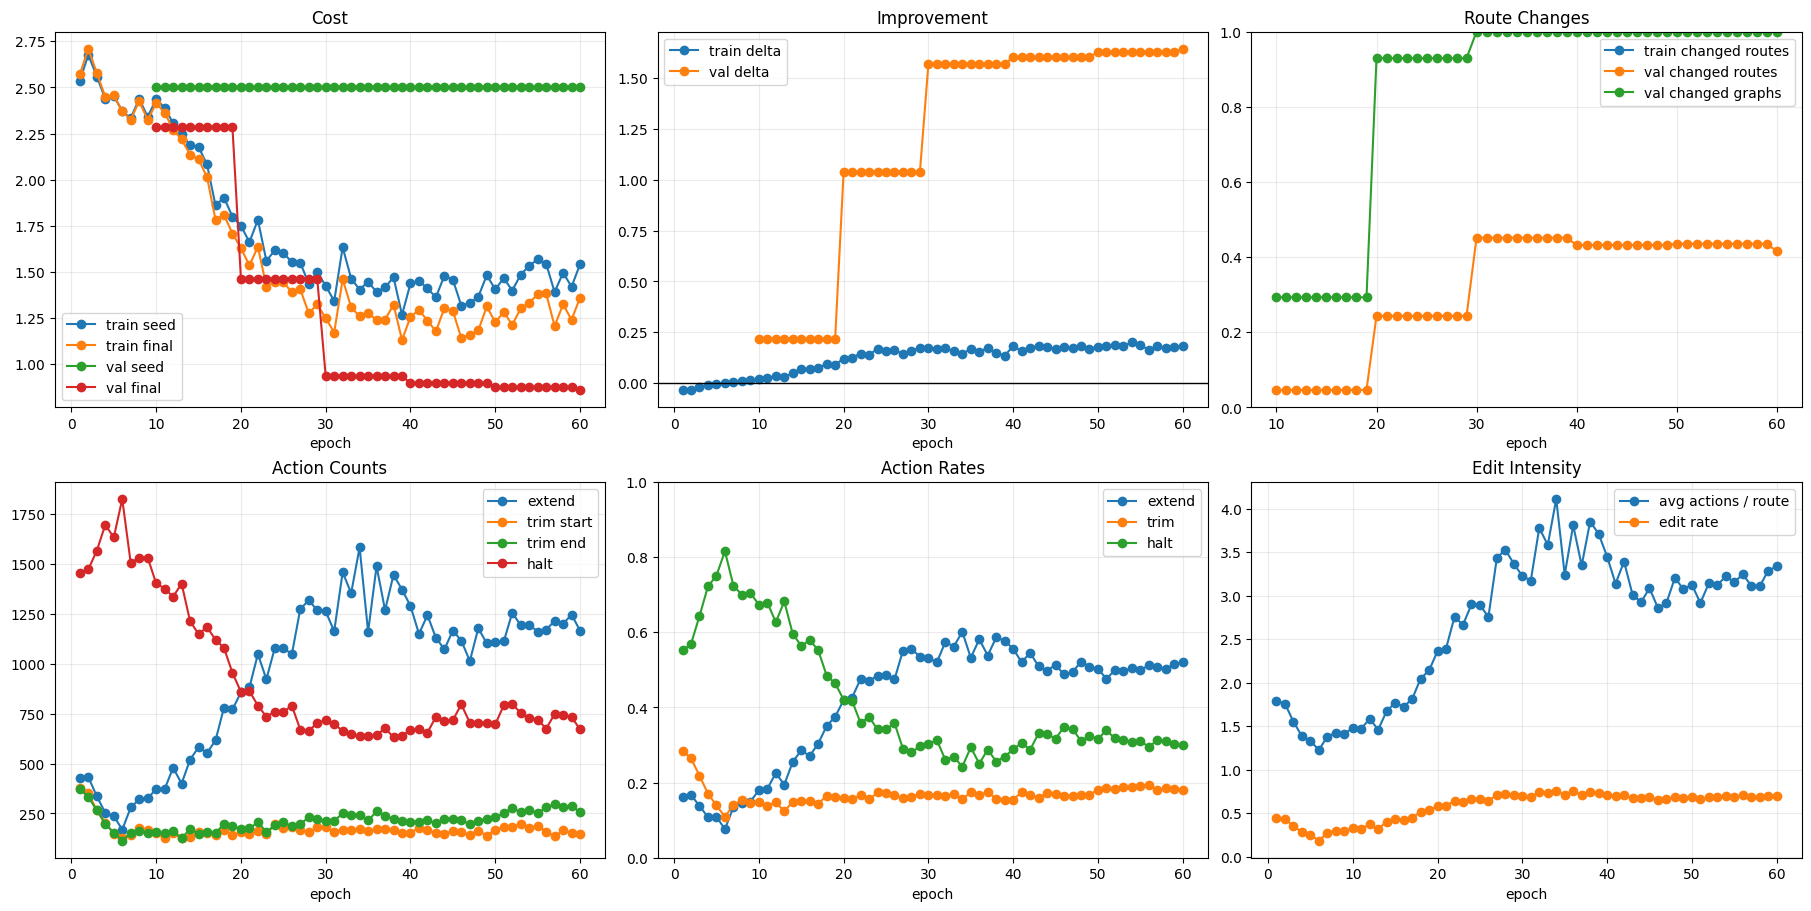

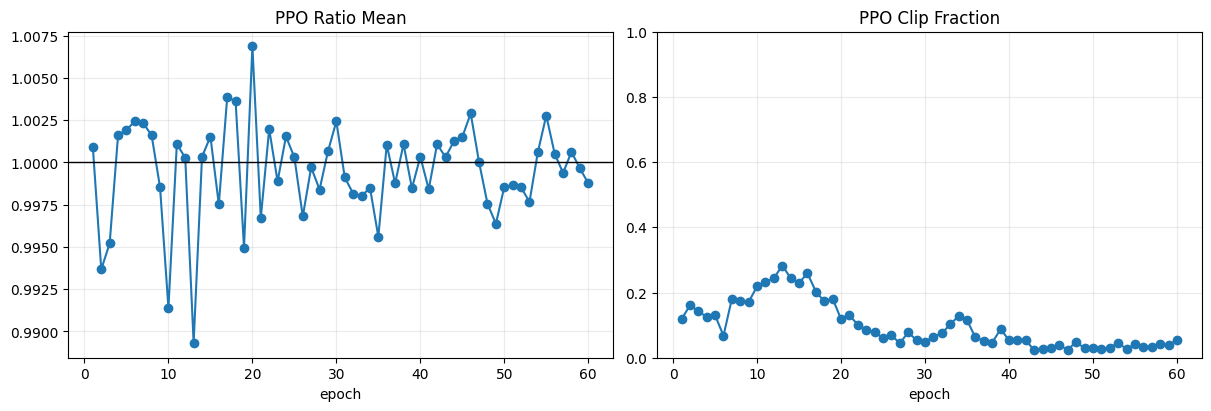

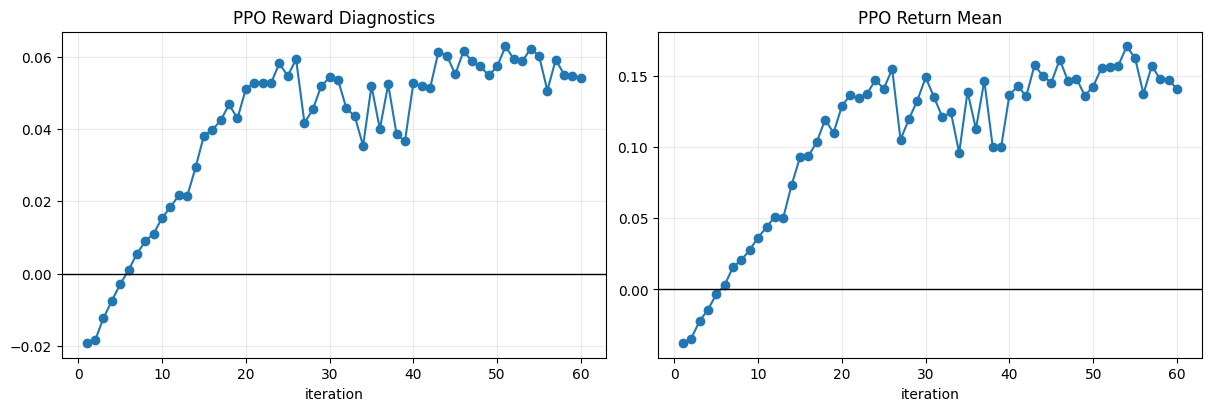

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

if "train_result" not in globals():
    raise RuntimeError("Run the training cell first so train_result is available.")

history_df = pd.DataFrame(train_result["history"])
display(history_df)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)

axes[0, 0].plot(history_df["epoch"], history_df["train_seed_cost"], marker="o", label="train seed")
axes[0, 0].plot(history_df["epoch"], history_df["train_final_cost"], marker="o", label="train final")
axes[0, 0].plot(history_df["epoch"], history_df["val_seed_cost"], marker="o", label="val seed")
axes[0, 0].plot(history_df["epoch"], history_df["val_final_cost"], marker="o", label="val final")
axes[0, 0].set_title("Cost")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.25)

axes[0, 1].plot(history_df["epoch"], history_df["train_delta"], marker="o", label="train delta")
axes[0, 1].plot(history_df["epoch"], history_df["val_delta"], marker="o", label="val delta")
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set_title("Improvement")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

axes[0, 2].plot(history_df["epoch"], history_df["train_changed_route_rate"], marker="o", label="train changed routes")
axes[0, 2].plot(history_df["epoch"], history_df["val_changed_route_rate"], marker="o", label="val changed routes")
axes[0, 2].plot(history_df["epoch"], history_df["val_changed_graph_rate"], marker="o", label="val changed graphs")
axes[0, 2].set_title("Route Changes")
axes[0, 2].set_xlabel("epoch")
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.25)

axes[1, 0].plot(history_df["epoch"], history_df["train_action_extend_count"], marker="o", label="extend")
axes[1, 0].plot(history_df["epoch"], history_df["train_action_trim_start_count"], marker="o", label="trim start")
axes[1, 0].plot(history_df["epoch"], history_df["train_action_trim_end_count"], marker="o", label="trim end")
axes[1, 0].plot(history_df["epoch"], history_df["train_action_halt_count"], marker="o", label="halt")
axes[1, 0].set_title("Action Counts")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.25)

axes[1, 1].plot(history_df["epoch"], history_df["train_action_extend_rate"], marker="o", label="extend")
axes[1, 1].plot(history_df["epoch"], history_df["train_action_trim_rate"], marker="o", label="trim")
axes[1, 1].plot(history_df["epoch"], history_df["train_action_halt_rate"], marker="o", label="halt")
axes[1, 1].set_title("Action Rates")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.25)

axes[1, 2].plot(history_df["epoch"], history_df["train_action_avg_actions_per_route"], marker="o", label="avg actions / route")
axes[1, 2].plot(history_df["epoch"], history_df["train_action_edit_rate"], marker="o", label="edit rate")
axes[1, 2].set_title("Edit Intensity")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.25)

plt.show()

if {"train_ppo_ratio_mean", "train_ppo_clip_fraction"}.issubset(history_df.columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    axes[0].plot(history_df["epoch"], history_df["train_ppo_ratio_mean"], marker="o")
    axes[0].axhline(1.0, color="black", linewidth=1)
    axes[0].set_title("PPO Ratio Mean")
    axes[0].set_xlabel("epoch")
    axes[0].grid(alpha=0.25)

    axes[1].plot(history_df["epoch"], history_df["train_ppo_clip_fraction"], marker="o")
    axes[1].set_title("PPO Clip Fraction")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.25)

    plt.show()

if {"train_reward_mean", "train_return_mean"}.issubset(history_df.columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    axes[0].plot(history_df["epoch"], history_df["train_reward_mean"], marker="o")
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("PPO Reward Diagnostics")
    axes[0].set_xlabel("iteration")
    axes[0].grid(alpha=0.25)

    axes[1].plot(history_df["epoch"], history_df["train_return_mean"], marker="o")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_title("PPO Return Mean")
    axes[1].set_xlabel("iteration")
    axes[1].grid(alpha=0.25)

    plt.show()


## 9. Final Validation And Route Export

In [ ]:
import pandas as pd

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(f"Train the model first or set BEST_MODEL_PATH: {BEST_MODEL_PATH}")

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
val = evaluate_lc_improvement(
    model,
    cost_obj,
    graphs,
    seed_routes,
    VAL_INDICES,
    device,
    MIN_ROUTE_LEN,
    MAX_ROUTE_LEN,
    batch_size=BATCH_SIZE,
    force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
    max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
    max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
    return_action_stats=True,
    target_n_routes=TARGET_N_ROUTES,
)

routes_path = VAL_ROUTES_PATH
torch.save(val["routes"], routes_path)

action_stats = val.get("action_stats", {})
action_rows = []
for action_name in ["extend", "trim_start", "trim_end", "trim", "halt", "edit"]:
    count_key = f"{action_name}_count"
    rate_key = f"{action_name}_rate"
    if count_key not in action_stats:
        continue
    action_rows.append(
        {
            "action": action_name,
            "count": int(action_stats[count_key]),
            "rate": float(action_stats.get(rate_key, 0.0)),
        }
    )

action_stats_df = pd.DataFrame(action_rows)

print(f"Validation target routes: {val['target_n_routes']}")
print(f"Validation seed cost:  {val['seed_cost']:.4f}")
print(f"Validation final cost: {val['final_cost']:.4f}")
print(f"Validation delta:      {val['delta']:.4f}")
print(f"Win rate:              {val['win_rate']:.2%}")
print(f"Changed route rate:    {val['changed_route_rate']:.2%}")
print(f"Changed graph rate:    {val['changed_graph_rate']:.2%}")
if action_stats:
    print(f"Route plans:           {int(action_stats['route_plan_count'])}")
    print(f"Total actions:         {int(action_stats['total_count'])}")
    print(f"Avg actions / route:   {action_stats['avg_actions_per_route']:.2f}")
print(f"Routes saved to:       {routes_path}")

if not action_stats_df.empty:
    display(action_stats_df)


eval:   0%|          | 0/4 [00:00<?, ?it/s]

Validation target routes: 10
Validation seed cost:  2.5016
Validation final cost: 0.8405
Validation delta:      1.6611
Win rate:              100.00%
Changed route rate:    46.06%
Changed graph rate:    100.00%
Route plans:           990
Total actions:         2644
Avg actions / route:   2.67
Routes saved to:       d:\PythonProjects\connectpt\examples\route_generator\lc_improvement_outputs\improvement_lc_improvement_trim_val_routes.pt


,action,count,rate
0,extend,1198,0.453101
1,trim_start,156,0.059002
2,trim_end,300,0.113464
3,trim,456,0.172466
4,halt,990,0.374433
5,edit,1654,0.625567


## 10. Balanced One-Graph Action GIF


Graph:                       947
GIF frames:                  48
Reward mode:                 diff_reward=True incumbent_reward=False zero_trim_reward=True
Return best routes:          False
Zero trim reward:            True
Reward scale:                1.0000
Edit step penalty:           0.0000
Forced halt penalty:         0.0000
Max trim actions per route:  1
Discount rate gamma:         1.0000
Seed cost:                   2.8711
Final cost:                  0.8963
Objective delta:             1.9748
Effective diff reward sum:   1.9748
Penalty sum:                 0.0000
Undiscounted shaped reward:  1.9748
Discounted reward sum:       1.9748
Discount reward gap:         +0.0000
Effective diff minus delta:  +0.000000
Shaped reward minus delta:   +0.000000
Action stats: {'extend_count': 30, 'trim_start_count': 2, 'trim_end_count': 5, 'halt_count': 10, 'total_count': 47, 'route_plan_count': 10, 'trim_count': 7, 'edit_count': 37, 'extend_rate': 0.6382978723404256, 'trim_start_rate': 0.04

,route,start_cost,final_cost,cost_improvement,raw_diff_reward,incumbent_raw_reward,edit_penalty,forced_halt_penalty,undiscounted_reward,discounted_reward,discount_gap,hit_edit_limit
0,0,2.871114,2.291511,0.579603,0.579603,0.579603,0.0,0.0,0.579603,0.579603,0.0,False
1,1,2.291511,1.829642,0.461869,0.461869,0.461869,0.0,0.0,0.461869,0.461869,0.0,False
2,2,1.829642,1.593974,0.235667,0.235667,0.235667,0.0,0.0,0.235667,0.235667,0.0,False
3,3,1.593974,1.599582,-0.005608,-0.005608,0.043692,0.0,0.0,-0.005608,-0.005608,0.0,False
4,4,1.599582,1.610320,-0.010738,-0.010738,0.027322,0.0,0.0,-0.010738,-0.010738,0.0,False
5,5,1.610320,1.615580,-0.005260,-0.005260,0.055007,0.0,0.0,-0.005260,-0.005260,0.0,False
6,6,1.615580,0.896297,0.719284,0.719284,0.719284,0.0,0.0,0.719284,0.719284,0.0,False
7,7,0.896297,0.896297,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,False
8,8,0.896296,0.896296,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,False
9,9,0.896297,0.896297,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,False


,action_kind,step_count,effective_diff_reward_sum,incumbent_raw_reward_sum,edit_penalty_sum,forced_halt_penalty_sum,reward_sum,discounted_reward_sum,mean_reward,positive_steps,negative_steps,hit_edit_limit_steps
0,extend,30,1.974817,1.825955,0.0,0.0,1.974817,1.974817,0.065827,8,22,0
1,halt,10,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0,0,0
2,trim_end,5,0.000000,0.198721,0.0,0.0,0.000000,0.000000,0.000000,0,0,0
3,trim_start,2,0.000000,0.097768,0.0,0.0,0.000000,0.000000,0.000000,0,0,0


,frame,route,step,action,short_action,action_kind,cost_before,reward_baseline_before,cost_after,cost_delta,...,trim_allowed_before,trim_count_before,trim_count_after,reward,discount,discounted_reward,cum_undiscounted_reward,cum_discounted_reward,hit_edit_limit,route_nodes
0,1,0,1,trim_end(23 -> 11),t_23_11,trim_end,2.871114,2.871114,2.847076,0.024038,...,True,0,1,0.000000,1.0,0.000000,0.000000,0.000000,False,17 -> 39 -> 16 -> 23
1,2,0,2,extend(23 -> 30),e_23_30,extend,2.847076,2.871114,2.291511,0.555565,...,False,1,1,0.579603,1.0,0.579603,0.579603,0.579603,False,17 -> 39 -> 16 -> 23 -> 27 -> 1 -> 29 -> 41 ->...
2,3,0,3,halt,h,halt,2.291511,2.291511,2.291511,0.000000,...,False,1,1,0.000000,1.0,0.000000,0.579603,0.579603,False,17 -> 39 -> 16 -> 23 -> 27 -> 1 -> 29 -> 41 ->...
3,4,1,1,trim_end(24 -> 38),t_24_38,trim_end,2.291511,2.291511,2.231297,0.060214,...,True,0,1,0.000000,1.0,0.000000,0.000000,0.000000,False,13 -> 24
4,5,1,2,extend(24 -> 25),e_24_25,extend,2.231297,2.291511,2.019192,0.212104,...,False,1,1,0.272318,1.0,0.272318,0.272318,0.272318,False,13 -> 24 -> 26 -> 14 -> 6 -> 25
5,6,1,3,extend(25 -> 23),e_25_23,extend,2.019192,2.019192,2.019763,-0.000571,...,False,1,1,-0.000571,1.0,-0.000571,0.271748,0.271748,False,13 -> 24 -> 26 -> 14 -> 6 -> 25 -> 23
6,7,1,4,extend(23 -> 16),e_23_16,extend,2.019763,2.019763,2.025711,-0.005948,...,False,1,1,-0.005948,1.0,-0.005948,0.265800,0.265800,False,13 -> 24 -> 26 -> 14 -> 6 -> 25 -> 23 -> 16
7,8,1,5,extend(16 -> 31),e_16_31,extend,2.025711,2.025711,1.829642,0.196069,...,False,1,1,0.196069,1.0,0.196069,0.461869,0.461869,False,13 -> 24 -> 26 -> 14 -> 6 -> 25 -> 23 -> 16 ->...
8,9,1,6,halt,h,halt,1.829642,1.829642,1.829642,0.000000,...,False,1,1,0.000000,1.0,0.000000,0.461869,0.461869,False,13 -> 24 -> 26 -> 14 -> 6 -> 25 -> 23 -> 16 ->...
9,10,2,1,trim_start(47 -> 18),t_47_18,trim_start,1.829642,1.829642,1.775566,0.054076,...,True,0,1,0.000000,1.0,0.000000,0.000000,0.000000,False,18 -> 44 -> 26 -> 14


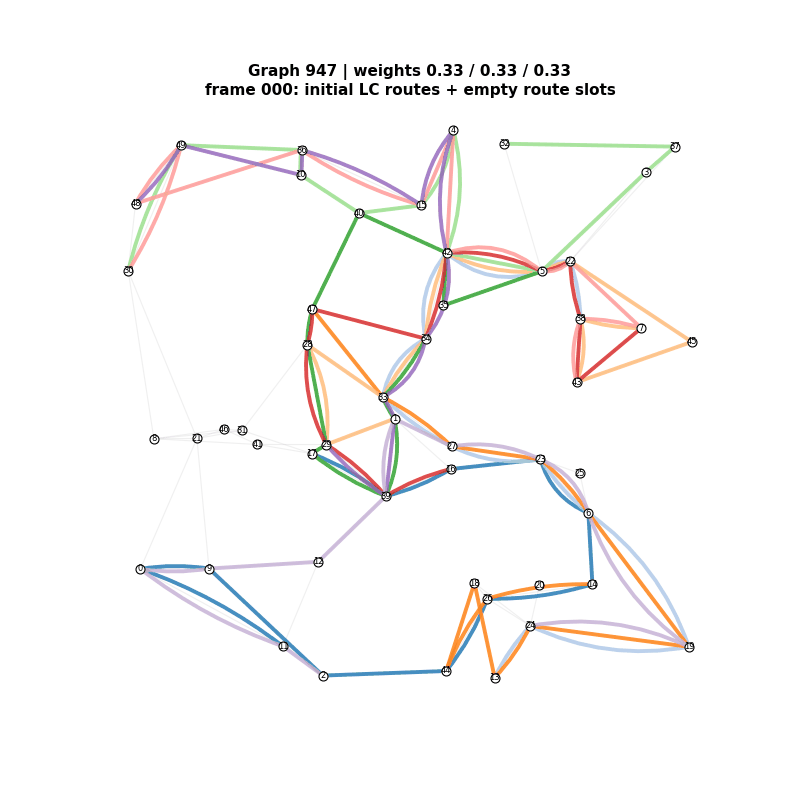

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from IPython.display import Image as IPyImage, display
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import FancyArrowPatch

from connectpt.routes_generator.improvement_learning import (
    _get_planned_current_routes,
    _make_route_context_state,
)
from connectpt.routes_generator.torch_utils import get_batch_tensor_from_routes
from connectpt.routes_generator.transit_time_estimator import (
    RouteGenBatchState,
    ROUTE_ACTION_EXTEND,
    ROUTE_ACTION_HALT,
    ROUTE_ACTION_TRIM_END,
    ROUTE_ACTION_TRIM_START,
)

GIF_GRAPH_POS = 90
GIF_GRAPH_IDX = int(VAL_INDICES[GIF_GRAPH_POS])
GIF_WEIGHTS = {
    "demand_time_weight": 0.33,
    "route_time_weight": 0.33,
    "median_connectivity_weight": 0.33,
}
GIF_FPS = 2
GIF_PATH = OUTPUT_DIR / f"{run_name}_graph_{GIF_GRAPH_IDX}_balanced_actions.gif"

ACTION_NAMES = {
    ROUTE_ACTION_EXTEND: "extend",
    ROUTE_ACTION_TRIM_START: "trim_start",
    ROUTE_ACTION_TRIM_END: "trim_end",
    ROUTE_ACTION_HALT: "halt",
}


def make_fixed_weight_dict(batch_size, weights):
    return {
        key: torch.full((batch_size,), float(value), device=device)
        for key, value in weights.items()
    }


def clean_route(route_tensor):
    if not torch.is_tensor(route_tensor):
        route_tensor = torch.as_tensor(route_tensor)
    return [int(node) for node in route_tensor.detach().cpu().tolist() if int(node) >= 0]


def action_text(action_kind, action):
    action_kind = int(action_kind)
    name = ACTION_NAMES[action_kind]
    if action_kind == ROUTE_ACTION_HALT:
        return name
    return f"{name}({int(action[0])} -> {int(action[1])})"


def is_trim_action_kind(action_kind):
    action_kind = int(action_kind)
    return action_kind in (ROUTE_ACTION_TRIM_START, ROUTE_ACTION_TRIM_END)


def short_action_text(action_kind, action):
    action_kind = int(action_kind)
    if action_kind == ROUTE_ACTION_HALT:
        return "h"
    from_node = int(action[0])
    to_node = int(action[1])
    if action_kind == ROUTE_ACTION_EXTEND:
        return f"e_{from_node}_{to_node}"
    if action_kind in (ROUTE_ACTION_TRIM_START, ROUTE_ACTION_TRIM_END):
        return f"t_{from_node}_{to_node}"
    return f"a_{from_node}_{to_node}"


def clone_weight_dict(weights):
    return {
        key: value.clone() if torch.is_tensor(value) else value
        for key, value in weights.items()
    }


def summarize_step_action_rows(steps_df, n_routes):
    total_count = int(len(steps_df))
    route_plan_count = int(n_routes)
    counts = steps_df["action_kind"].value_counts() if not steps_df.empty else {}
    extend_count = int(counts.get("extend", 0))
    trim_start_count = int(counts.get("trim_start", 0))
    trim_end_count = int(counts.get("trim_end", 0))
    halt_count = int(counts.get("halt", 0))
    trim_count = trim_start_count + trim_end_count
    edit_count = extend_count + trim_count
    denom = max(total_count, 1)
    return {
        "extend_count": extend_count,
        "trim_start_count": trim_start_count,
        "trim_end_count": trim_end_count,
        "halt_count": halt_count,
        "total_count": total_count,
        "route_plan_count": route_plan_count,
        "trim_count": trim_count,
        "edit_count": edit_count,
        "extend_rate": extend_count / denom,
        "trim_start_rate": trim_start_count / denom,
        "trim_end_rate": trim_end_count / denom,
        "halt_rate": halt_count / denom,
        "trim_rate": trim_count / denom,
        "edit_rate": edit_count / denom,
        "avg_actions_per_route": total_count / max(route_plan_count, 1),
    }


def build_completed_route_state(graph_batch, routes, weights):
    state = RouteGenBatchState(
        graph_batch,
        cost_obj,
        routes.shape[1],
        MIN_ROUTE_LEN,
        MAX_ROUTE_LEN,
        cost_weights=clone_weight_dict(weights),
    )
    state.add_new_routes(routes)
    return state


def undirected_edge_key(edge):
    return tuple(sorted((int(edge[0]), int(edge[1]))))


def build_edge_overlap_map(routes):
    edge_to_routes = {}
    for route_idx, route_tensor in enumerate(routes.detach().cpu()):
        route = clean_route(route_tensor)
        for edge in zip(route[:-1], route[1:]):
            edge_to_routes.setdefault(undirected_edge_key(edge), set()).add(route_idx)

    overlap_map = {}
    for edge_key, route_idxs in edge_to_routes.items():
        ordered_route_idxs = sorted(route_idxs)
        count = len(ordered_route_idxs)
        for pos, route_idx in enumerate(ordered_route_idxs):
            overlap_map[(route_idx, edge_key)] = (pos, count)
    return overlap_map


def overlapping_edge_rad(route_idx, edge, overlap_map, base_step=0.16, max_rad=0.28):
    edge_key = undirected_edge_key(edge)
    pos, count = overlap_map.get((route_idx, edge_key), (0, 1))
    if count <= 1:
        return 0.0

    centered_pos = pos - (count - 1) / 2.0
    max_centered_pos = max((count - 1) / 2.0, 1.0)
    step = min(base_step, max_rad / max_centered_pos)
    direction_sign = 1.0 if tuple(edge) == edge_key else -1.0
    return centered_pos * step * direction_sign


def draw_route_edge(ax, coords, edge, *, color, linewidth, alpha, route_idx,
                    overlap_map, linestyle="-", zorder=3):
    start, end = edge
    rad = overlapping_edge_rad(route_idx, edge, overlap_map)
    start_xy = coords[start]
    end_xy = coords[end]

    if abs(rad) < 1e-9:
        ax.plot(
            [start_xy[0], end_xy[0]],
            [start_xy[1], end_xy[1]],
            color=color,
            linewidth=linewidth,
            alpha=alpha,
            linestyle=linestyle,
            solid_capstyle="round",
            zorder=zorder,
        )
        return

    patch = FancyArrowPatch(
        posA=start_xy,
        posB=end_xy,
        arrowstyle="-",
        connectionstyle=f"arc3,rad={rad:.4f}",
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        linestyle=linestyle,
        shrinkA=0,
        shrinkB=0,
        mutation_scale=1,
        zorder=zorder,
    )
    ax.add_patch(patch)


def draw_action_frame(ax, graph, routes, frame):
    routes = routes.detach().cpu()
    coords = graph[STOP_KEY].pos.detach().cpu().numpy()
    street_adj = graph.street_adj.detach().cpu().numpy()
    n_nodes = coords.shape[0]
    n_routes = routes.shape[0]
    colors = plt.cm.tab20(np.linspace(0, 1, max(20, n_routes)))
    overlap_map = build_edge_overlap_map(routes)

    for start in range(n_nodes):
        for end in range(start + 1, n_nodes):
            if np.isfinite(street_adj[start, end]) or np.isfinite(street_adj[end, start]):
                ax.plot(
                    [coords[start, 0], coords[end, 0]],
                    [coords[start, 1], coords[end, 1]],
                    color="lightgray",
                    linewidth=0.8,
                    alpha=0.35,
                    zorder=1,
                )

    for route_idx, route_tensor in enumerate(routes):
        route = clean_route(route_tensor)
        if len(route) < 2:
            continue
        color = colors[route_idx % len(colors)]
        is_active = route_idx == frame["route_idx"]
        linewidth = 4.2 if is_active else 2.8
        alpha = 1.0 if is_active else 0.82

        for edge in zip(route[:-1], route[1:]):
            draw_route_edge(
                ax,
                coords,
                edge,
                color=color,
                linewidth=linewidth,
                alpha=alpha,
                route_idx=route_idx,
                overlap_map=overlap_map,
                zorder=3 if not is_active else 4,
            )
        ax.scatter(
            coords[route, 0],
            coords[route, 1],
            color=[color],
            s=34 if not is_active else 52,
            edgecolor="black" if is_active else "white",
            linewidth=0.8,
            zorder=5,
        )

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        s=42,
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        zorder=6,
    )
    for node_idx, (x_coord, y_coord) in enumerate(coords):
        ax.text(
            x_coord,
            y_coord,
            str(node_idx),
            fontsize=6,
            ha="center",
            va="center",
            zorder=7,
        )

    ax.set_title(
        f"Graph {GIF_GRAPH_IDX} | weights 0.33 / 0.33 / 0.33\n"
        f"frame {frame['frame']:03d}: {frame['label']}",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_aspect("equal")
    ax.axis("off")


def put_route(display_routes, route_idx, route):
    display_routes = display_routes.clone()
    display_routes[:, route_idx] = -1
    route = route[route > -1].to(display_routes.device)
    if route.numel() == 0:
        return display_routes
    route_tensor = get_batch_tensor_from_routes(
        [[route]],
        display_routes.device,
        max_route_len=display_routes.shape[-1],
    )
    display_routes[:, route_idx] = route_tensor[:, 0]
    return display_routes


def collect_balanced_action_frames(graph_idx):
    batch_indices = torch.tensor([int(graph_idx)], dtype=torch.long)
    graph_batch, route_batch = make_improvement_batch(
        graphs,
        seed_routes,
        batch_indices,
        device,
        training=False,
        target_n_routes=TARGET_N_ROUTES,
    )
    weights = make_fixed_weight_dict(1, GIF_WEIGHTS)
    reward_scale = float(getattr(cfg, "reward_scale", 1.0))
    gamma = float(getattr(cfg, "discount_rate", 1.0))
    diff_reward = bool(getattr(cfg, "diff_reward", True))
    incumbent_reward = bool(getattr(cfg, "incumbent_reward", False))
    return_best_routes = bool(getattr(cfg, "return_best_routes", False))
    zero_trim_reward = bool(getattr(cfg, "zero_trim_reward", False))
    edit_step_penalty = float(getattr(cfg, "edit_step_penalty", 0.0))
    forced_halt_penalty = float(getattr(cfg, "forced_halt_penalty", 0.0))
    max_trim_actions_per_route = MAX_TRIM_ACTIONS_PER_ROUTE

    context_route_len = max(
        int(route_batch.shape[-1]),
        int(MAX_ROUTE_LEN),
        int(graph_batch[STOP_KEY].num_nodes),
    )
    working_route_batch = torch.full(
        (1, route_batch.shape[1], context_route_len),
        -1,
        dtype=route_batch.dtype,
        device=device,
    )
    working_route_batch[..., :route_batch.shape[-1]] = route_batch
    display_route_batch = working_route_batch.clone()

    frames = [
        {
            "frame": 0,
            "route_idx": None,
            "step_idx": 0,
            "label": "initial LC routes + empty route slots",
            "routes": display_route_batch[0].detach().cpu(),
        }
    ]
    rows = []
    route_reward_rows = []

    model.eval()
    frame_idx = 1
    with torch.no_grad():
        for route_idx in range(route_batch.shape[1]):
            # Unified context: every slot sees the working batch with its own
            # slot blanked out. invalid_directly_connected fires only when the
            # remaining context has no real stops (network is empty).
            context_routes = working_route_batch.clone()
            context_routes[:, route_idx] = -1
            invalid_directly_connected = not bool(
                (context_routes >= 0).any().item()
            )
            route_state = _make_route_context_state(
                cost_obj,
                graph_batch,
                working_route_batch,
                route_idx,
                MIN_ROUTE_LEN,
                MAX_ROUTE_LEN,
                weights,
                invalid_directly_connected=invalid_directly_connected,
            )
            context_route_counts = route_state.n_finished_routes.detach().clone()
            route_state = model.setup_planning(route_state)
            start_result = cost_obj(route_state)
            prev_cost = start_result.cost.detach().clone()
            current_cost = prev_cost.clone()
            best_cost = prev_cost.clone()
            best_planned_route = _get_planned_current_routes(
                route_state,
                route_batch[:, route_idx],
                context_route_counts,
            )[0]
            route_start_cost = float(prev_cost.cpu()[0])
            route_effective_diff_reward = 0.0
            route_incumbent_raw_reward = 0.0
            route_edit_penalty = 0.0
            route_forced_halt_penalty = 0.0
            route_undiscounted_reward = 0.0
            route_discounted_reward = 0.0
            hit_edit_limit = False
            reward_step_idx = 0
            trim_action_count = 0

            for step_idx in range(MAX_ROUTE_EDIT_STEPS + 1):
                if route_state.is_done().all():
                    break

                force_halt = step_idx >= MAX_ROUTE_EDIT_STEPS
                trim_allowed = (
                    max_trim_actions_per_route is None or
                    trim_action_count < int(max_trim_actions_per_route)
                )
                if force_halt:
                    hit_edit_limit = True
                    step_kinds = torch.full(
                        (1,),
                        ROUTE_ACTION_HALT,
                        dtype=torch.long,
                        device=device,
                    )
                    step_actions = torch.full((1, 2), -1, dtype=torch.long, device=device)
                else:
                    step_kinds, step_actions, _, _ = model.step_route_action(
                        route_state,
                        greedy=True,
                        allow_halt=not (FORCE_NONHALT_FIRST_STEP and step_idx == 0),
                        allow_trim_start=trim_allowed,
                        allow_trim_end=trim_allowed,
                    )

                label = action_text(step_kinds[0], step_actions[0])
                short_label = short_action_text(step_kinds[0], step_actions[0])
                action_kind_id = int(step_kinds[0].item())
                action_kind_name = ACTION_NAMES[action_kind_id]
                is_trim_action = is_trim_action_kind(action_kind_id)
                reward_baseline_before = float(prev_cost.cpu()[0])
                cost_before = float(current_cost.cpu()[0])
                best_cost_before = float(best_cost.cpu()[0])
                route_state.apply_route_actions(step_kinds, step_actions)
                step_result = cost_obj(route_state)
                new_cost = step_result.cost.detach().clone()
                cost_after = float(new_cost.cpu()[0])
                new_best_cost = torch.minimum(best_cost, new_cost)
                best_cost_after = float(new_best_cost.cpu()[0])
                raw_diff_reward_tensor = (prev_cost - new_cost) * reward_scale
                if zero_trim_reward and is_trim_action:
                    raw_diff_reward_tensor = torch.zeros_like(raw_diff_reward_tensor)
                raw_diff_reward = float(raw_diff_reward_tensor.cpu()[0])
                incumbent_raw_reward = float(((best_cost - new_best_cost) * reward_scale).cpu()[0])
                if incumbent_reward:
                    step_reward_tensor = (best_cost - new_best_cost) * reward_scale
                elif diff_reward:
                    step_reward_tensor = (prev_cost - new_cost) * reward_scale
                else:
                    step_reward_tensor = torch.zeros_like(new_cost)
                    if int(step_kinds[0].item()) == ROUTE_ACTION_HALT:
                        step_reward_tensor = -new_cost * reward_scale
                if zero_trim_reward and is_trim_action:
                    step_reward_tensor = torch.zeros_like(step_reward_tensor)
                trim_action_count_before = trim_action_count
                if is_trim_action:
                    trim_action_count += 1
                edit_penalty_value = 0.0
                if int(step_kinds[0].item()) != ROUTE_ACTION_HALT:
                    edit_penalty_value = edit_step_penalty
                    step_reward_tensor = step_reward_tensor - edit_step_penalty
                forced_halt_penalty_value = 0.0
                if force_halt:
                    forced_halt_penalty_value = forced_halt_penalty
                    step_reward_tensor = step_reward_tensor - forced_halt_penalty
                step_reward = float(step_reward_tensor.cpu()[0])
                discount = gamma ** reward_step_idx
                discounted_reward = discount * step_reward
                route_effective_diff_reward += raw_diff_reward
                route_incumbent_raw_reward += incumbent_raw_reward
                route_edit_penalty += edit_penalty_value
                route_forced_halt_penalty += forced_halt_penalty_value
                route_undiscounted_reward += step_reward
                route_discounted_reward += discounted_reward

                planned_route = _get_planned_current_routes(
                    route_state,
                    route_batch[:, route_idx],
                    context_route_counts,
                )[0]
                is_new_best = bool((new_cost < best_cost).cpu()[0])
                if is_new_best:
                    best_planned_route = planned_route.clone()
                best_cost = new_best_cost
                current_cost = new_cost
                if not (zero_trim_reward and is_trim_action):
                    prev_cost = new_cost
                display_step_routes = put_route(
                    display_route_batch,
                    route_idx,
                    planned_route,
                )

                frames.append(
                    {
                        "frame": frame_idx,
                        "route_idx": route_idx,
                        "step_idx": step_idx + 1,
                        "label": (
                            f"R{route_idx} step {step_idx + 1}: {short_label} ({label}) "
                            f"r={step_reward:+.4f} disc={discounted_reward:+.4f}"
                        ),
                        "routes": display_step_routes[0].detach().cpu(),
                    }
                )
                rows.append(
                    {
                        "frame": frame_idx,
                        "route": route_idx,
                        "step": step_idx + 1,
                        "action": label,
                        "short_action": short_label,
                        "action_kind": action_kind_name,
                        "cost_before": cost_before,
                        "reward_baseline_before": reward_baseline_before,
                        "cost_after": cost_after,
                        "cost_delta": cost_before - cost_after,
                        "raw_diff_reward": raw_diff_reward,
                        "incumbent_raw_reward": incumbent_raw_reward,
                        "best_cost_before": best_cost_before,
                        "best_cost_after": best_cost_after,
                        "regret_after_best": cost_after - best_cost_after,
                        "is_new_best": is_new_best,
                        "edit_penalty": edit_penalty_value,
                        "forced_halt_penalty": forced_halt_penalty_value,
                        "trim_allowed_before": trim_allowed,
                        "trim_count_before": trim_action_count_before,
                        "trim_count_after": trim_action_count,
                        "reward": step_reward,
                        "discount": discount,
                        "discounted_reward": discounted_reward,
                        "cum_undiscounted_reward": route_undiscounted_reward,
                        "cum_discounted_reward": route_discounted_reward,
                        "hit_edit_limit": bool(force_halt),
                        "route_nodes": " -> ".join(map(str, clean_route(planned_route))),
                    }
                )
                frame_idx += 1
                reward_step_idx += 1

                if int(step_kinds[0].item()) == ROUTE_ACTION_HALT:
                    break

            route_final_cost = float((best_cost if return_best_routes else current_cost).cpu()[0])
            route_reward_rows.append(
                {
                    "route": route_idx,
                    "start_cost": route_start_cost,
                    "final_cost": route_final_cost,
                    "cost_improvement": route_start_cost - route_final_cost,
                    "raw_diff_reward": route_effective_diff_reward,
                    "incumbent_raw_reward": route_incumbent_raw_reward,
                    "edit_penalty": route_edit_penalty,
                    "forced_halt_penalty": route_forced_halt_penalty,
                    "undiscounted_reward": route_undiscounted_reward,
                    "discounted_reward": route_discounted_reward,
                    "discount_gap": route_discounted_reward - route_undiscounted_reward,
                    "hit_edit_limit": hit_edit_limit,
                }
            )
            if return_best_routes:
                final_route = best_planned_route
            else:
                final_route = _get_planned_current_routes(
                    route_state,
                    route_batch[:, route_idx],
                    context_route_counts,
                )[0]
            display_route_batch = put_route(display_route_batch, route_idx, final_route)
            working_route_batch = put_route(working_route_batch, route_idx, final_route)

    steps_df = pd.DataFrame(rows)
    action_stats = summarize_step_action_rows(steps_df, route_batch.shape[1])

    seed_state = build_completed_route_state(graph_batch, route_batch, weights)
    seed_result = cost_obj(seed_state)
    final_state = build_completed_route_state(graph_batch, working_route_batch, weights)
    final_result = cost_obj(final_state)

    _, static_seed_result, static_final_result, _, _, static_actions, static_action_kinds = rollout_lc_improvement(
        model,
        cost_obj,
        graph_batch,
        route_batch,
        MIN_ROUTE_LEN,
        MAX_ROUTE_LEN,
        greedy=True,
        cost_weights=weights,
        return_actions=True,
        force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
        max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
        max_trim_actions_per_route=max_trim_actions_per_route,
        return_best_routes=return_best_routes,
    )
    static_action_stats = summarize_route_action_stats(static_actions, static_action_kinds)
    rollout_comparison = {
        "static_seed_cost": float(static_seed_result.cost.detach().cpu()[0]),
        "static_final_cost": float(static_final_result.cost.detach().cpu()[0]),
        "static_delta": float((static_seed_result.cost - static_final_result.cost).detach().cpu()[0]),
        "static_total_actions": int(static_action_stats["total_count"]),
        "static_avg_actions_per_route": float(static_action_stats["avg_actions_per_route"]),
    }
    return (
        graph_batch,
        frames,
        steps_df,
        pd.DataFrame(route_reward_rows),
        seed_result,
        final_result,
        action_stats,
        rollout_comparison,
    )


(
    graph_batch,
    gif_frames,
    gif_steps_df,
    gif_reward_summary_df,
    gif_seed_result,
    gif_final_result,
    gif_action_stats,
    gif_rollout_comparison,
) = collect_balanced_action_frames(GIF_GRAPH_IDX)

objective_delta = (gif_seed_result.cost - gif_final_result.cost).item()
reward_total = float(gif_reward_summary_df["undiscounted_reward"].sum())
discounted_reward_total = float(gif_reward_summary_df["discounted_reward"].sum())
discount_gap = discounted_reward_total - reward_total
print(f"Graph:                       {GIF_GRAPH_IDX}")
print(f"GIF frames:                  {len(gif_frames)}")
print(
    "Reward mode:                 "
    f"diff_reward={bool(getattr(cfg, 'diff_reward', True))} "
    f"incumbent_reward={bool(getattr(cfg, 'incumbent_reward', False))} "
    f"zero_trim_reward={bool(getattr(cfg, 'zero_trim_reward', False))}"
)
print(f"Return best routes:          {bool(getattr(cfg, 'return_best_routes', False))}")
print(f"Zero trim reward:            {bool(getattr(cfg, 'zero_trim_reward', False))}")
print(f"Reward scale:                {float(getattr(cfg, 'reward_scale', 1.0)):.4f}")
print(f"Edit step penalty:           {float(getattr(cfg, 'edit_step_penalty', 0.0)):.4f}")
print(f"Forced halt penalty:         {float(getattr(cfg, 'forced_halt_penalty', 0.0)):.4f}")
print(f"Max trim actions per route:  {MAX_TRIM_ACTIONS_PER_ROUTE}")
print(f"Discount rate gamma:         {float(getattr(cfg, 'discount_rate', 1.0)):.4f}")
print(f"Seed cost:                   {gif_seed_result.cost.item():.4f}")
print(f"Final cost:                  {gif_final_result.cost.item():.4f}")
effective_diff_reward_total = float(gif_reward_summary_df["raw_diff_reward"].sum())
penalty_total = float(gif_reward_summary_df["edit_penalty"].sum() + gif_reward_summary_df["forced_halt_penalty"].sum())
print(f"Objective delta:             {objective_delta:.4f}")
print(f"Effective diff reward sum:   {effective_diff_reward_total:.4f}")
print(f"Penalty sum:                 {penalty_total:.4f}")
print(f"Undiscounted shaped reward:  {reward_total:.4f}")
print(f"Discounted reward sum:       {discounted_reward_total:.4f}")
print(f"Discount reward gap:         {discount_gap:+.4f}")
if bool(getattr(cfg, "diff_reward", True)) and not bool(getattr(cfg, "incumbent_reward", False)):
    print(f"Effective diff minus delta:  {effective_diff_reward_total - objective_delta:+.6f}")
if bool(getattr(cfg, "incumbent_reward", False)):
    incumbent_reward_total = float(gif_reward_summary_df["incumbent_raw_reward"].sum())
    print(f"Incumbent raw reward sum:    {incumbent_reward_total:.4f}")
print(f"Shaped reward minus delta:   {reward_total - objective_delta:+.6f}")
print("Action stats:", gif_action_stats)
print(
    "Static rollout comparison:",
    gif_rollout_comparison,
    "(rollout_lc_improvement uses model.plan_new_route)",
)
print(f"GIF path:                    {GIF_PATH}")

display(gif_reward_summary_df)
gif_action_reward_report_df = (
    gif_steps_df.groupby("action_kind", as_index=False)
    .agg(
        step_count=("reward", "size"),
        effective_diff_reward_sum=("raw_diff_reward", "sum"),
        incumbent_raw_reward_sum=("incumbent_raw_reward", "sum"),
        edit_penalty_sum=("edit_penalty", "sum"),
        forced_halt_penalty_sum=("forced_halt_penalty", "sum"),
        reward_sum=("reward", "sum"),
        discounted_reward_sum=("discounted_reward", "sum"),
        mean_reward=("reward", "mean"),
        positive_steps=("reward", lambda values: int((values > 0).sum())),
        negative_steps=("reward", lambda values: int((values < 0).sum())),
        hit_edit_limit_steps=("hit_edit_limit", "sum"),
    )
    .sort_values("reward_sum", ascending=False)
)
display(gif_action_reward_report_df)
step_reward_columns = [
    "frame", "route", "step", "action", "short_action", "action_kind", "cost_before",
    "reward_baseline_before", "cost_after",
    "cost_delta", "raw_diff_reward", "incumbent_raw_reward",
    "best_cost_before", "best_cost_after", "regret_after_best", "is_new_best",
    "edit_penalty", "forced_halt_penalty", "trim_allowed_before",
    "trim_count_before", "trim_count_after",
    "reward", "discount", "discounted_reward",
    "cum_undiscounted_reward", "cum_discounted_reward",
    "hit_edit_limit", "route_nodes",
]
display(gif_steps_df[step_reward_columns])

fig, ax = plt.subplots(figsize=(8, 8))

def update_gif(frame_pos):
    ax.clear()
    draw_action_frame(ax, graphs[GIF_GRAPH_IDX], gif_frames[frame_pos]["routes"], gif_frames[frame_pos])
    return []

animation = FuncAnimation(
    fig,
    update_gif,
    frames=len(gif_frames),
    interval=1000 / GIF_FPS,
    blit=False,
)

try:
    animation.save(GIF_PATH, writer=PillowWriter(fps=GIF_FPS))
    plt.close(fig)
    display(IPyImage(filename=str(GIF_PATH)))
except Exception as exc:
    plt.close(fig)
    print(f"Could not save GIF with PillowWriter: {exc}")
    fig, ax = plt.subplots(figsize=(8, 8))
    draw_action_frame(ax, graphs[GIF_GRAPH_IDX], gif_frames[-1]["routes"], gif_frames[-1])
    plt.show()


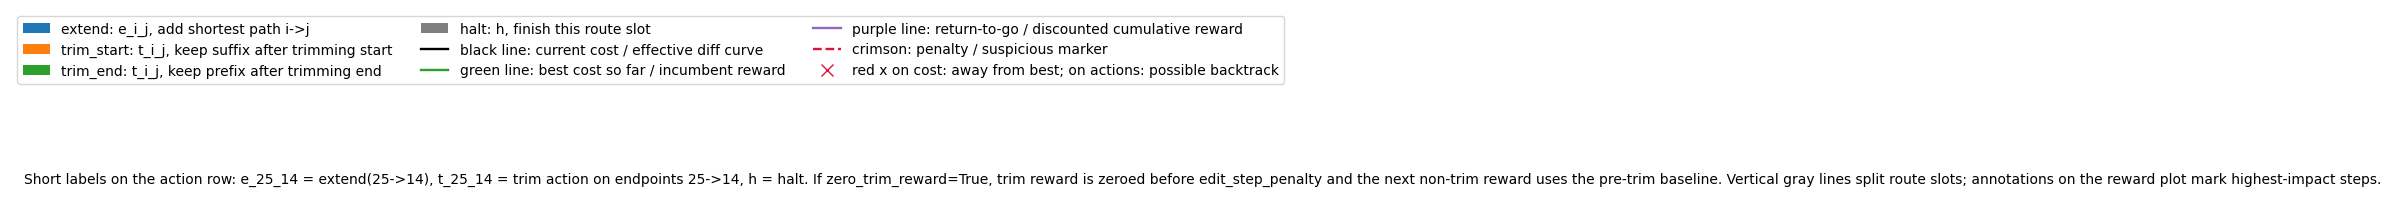

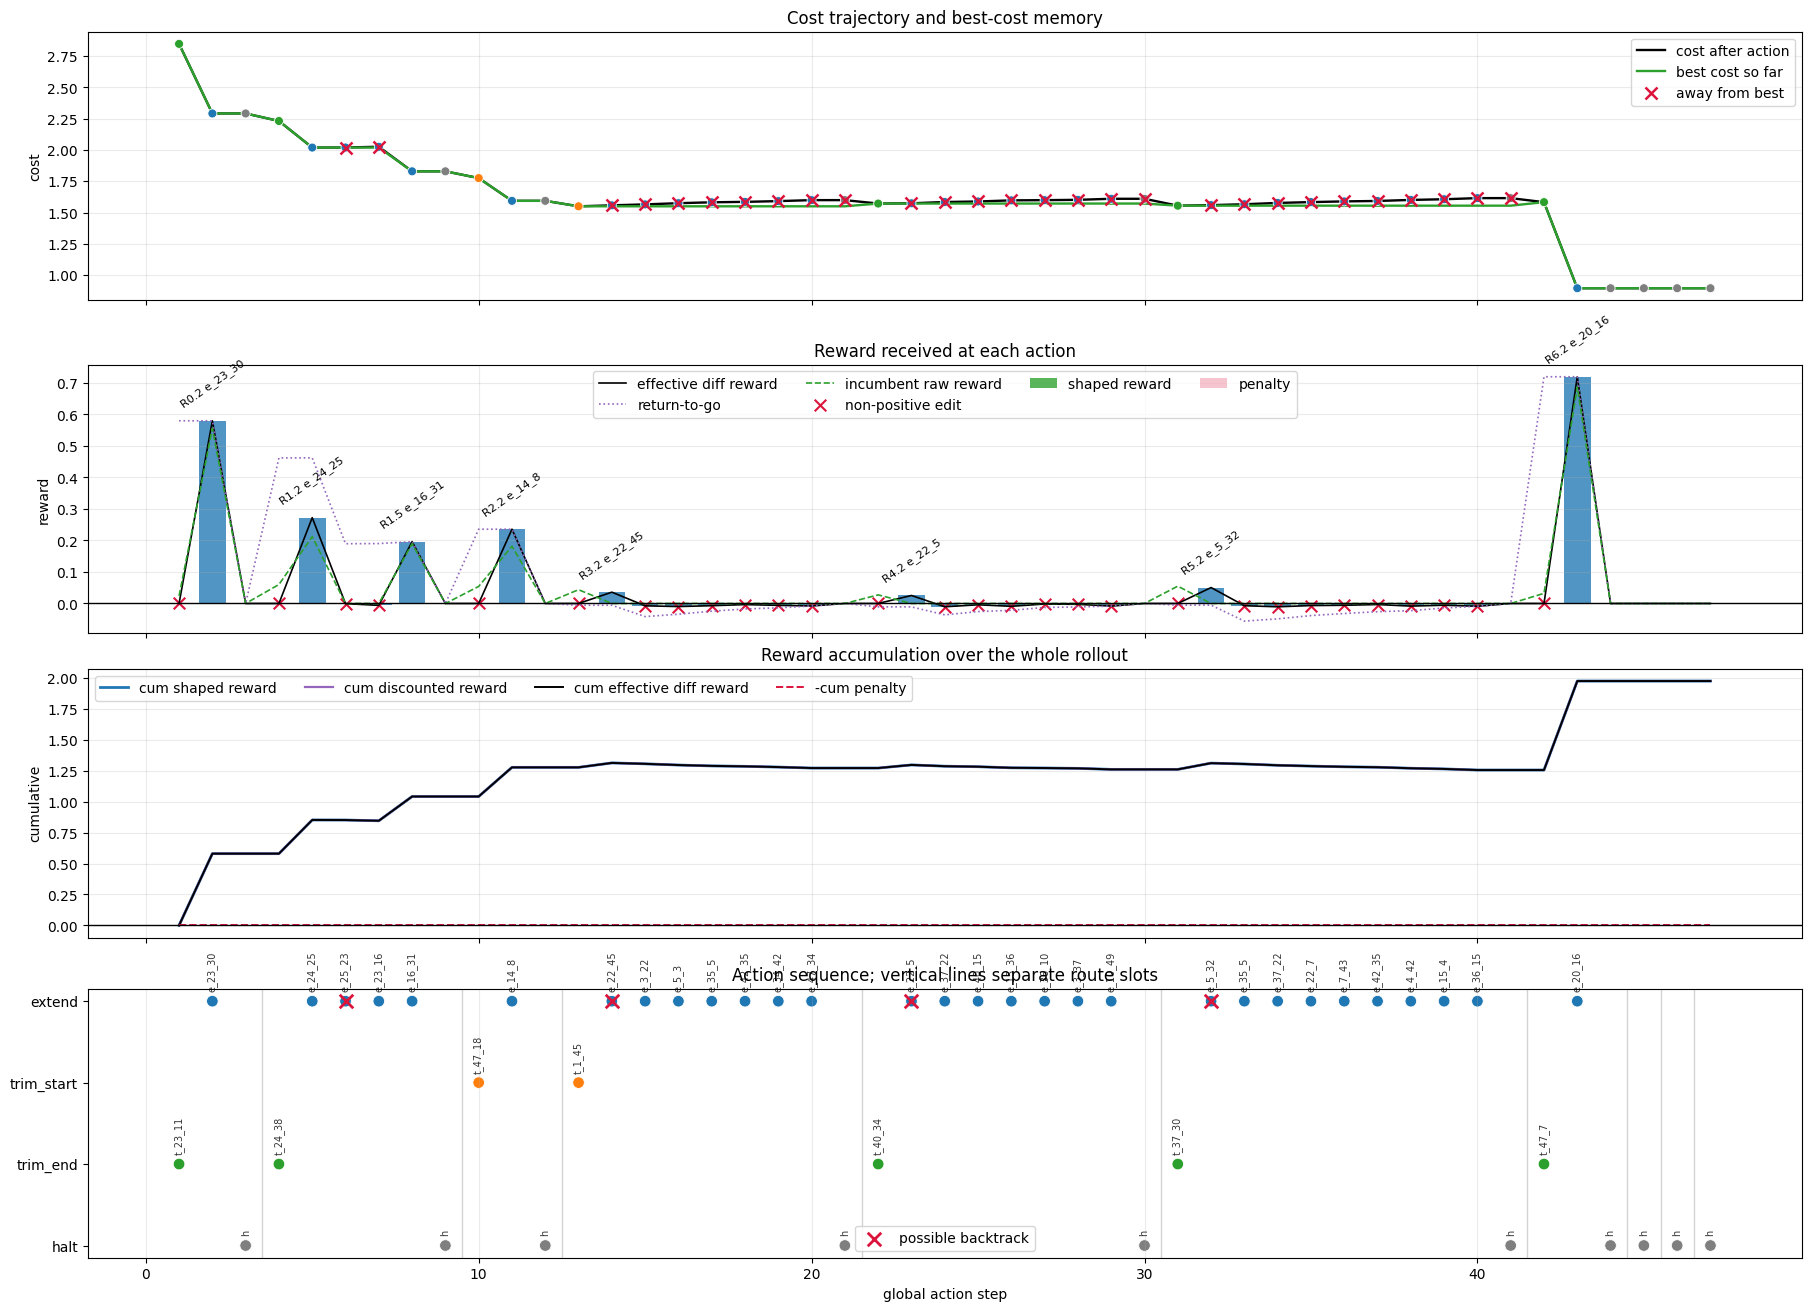

Steps worth inspecting: non-positive edit reward, moved away from best, or possible backtrack


,global_step,route,step,action,short_action,action_kind,cost_before,cost_after,cost_delta,best_cost_before,...,raw_diff_reward,incumbent_raw_reward,penalty_total,reward,return_to_go,cum_reward_global,is_new_best,moved_away_from_best,possible_backtrack,route_nodes
0,1,0,1,trim_end(23 -> 11),t_23_11,trim_end,2.871114,2.847076,0.024038,2.871114,...,0.000000,0.024038,0.0,0.000000,0.579603,0.000000,True,False,False,17 -> 39 -> 16 -> 23
3,4,1,1,trim_end(24 -> 38),t_24_38,trim_end,2.291511,2.231297,0.060214,2.291511,...,0.000000,0.060214,0.0,0.000000,0.461869,0.579603,True,False,False,13 -> 24
5,6,1,3,extend(25 -> 23),e_25_23,extend,2.019192,2.019763,-0.000571,2.019192,...,-0.000571,0.000000,0.0,-0.000571,0.189551,0.851351,False,True,True,13 -> 24 -> 26 -> 14 -> 6 -> 25 -> 23
6,7,1,4,extend(23 -> 16),e_23_16,extend,2.019763,2.025711,-0.005948,2.019192,...,-0.005948,0.000000,0.0,-0.005948,0.190121,0.845403,False,True,False,13 -> 24 -> 26 -> 14 -> 6 -> 25 -> 23 -> 16
9,10,2,1,trim_start(47 -> 18),t_47_18,trim_start,1.829642,1.775566,0.054076,1.829642,...,0.000000,0.054076,0.0,0.000000,0.235667,1.041472,True,False,False,18 -> 44 -> 26 -> 14
12,13,3,1,trim_start(1 -> 45),t_1_45,trim_start,1.593974,1.550282,0.043692,1.593974,...,0.000000,0.043692,0.0,0.000000,-0.005608,1.277140,True,False,False,45 -> 43 -> 38 -> 7
13,14,3,2,extend(22 -> 45),e_22_45,extend,1.550282,1.558109,-0.007827,1.550282,...,0.035866,0.000000,0.0,0.035866,-0.005608,1.313005,False,True,True,22 -> 45 -> 43 -> 38 -> 7
14,15,3,3,extend(3 -> 22),e_3_22,extend,1.558109,1.565515,-0.007406,1.550282,...,-0.007406,0.000000,0.0,-0.007406,-0.041474,1.305599,False,True,False,3 -> 22 -> 45 -> 43 -> 38 -> 7
15,16,3,4,extend(5 -> 3),e_5_3,extend,1.565515,1.575223,-0.009708,1.550282,...,-0.009708,0.000000,0.0,-0.009708,-0.034068,1.295891,False,True,False,5 -> 3 -> 22 -> 45 -> 43 -> 38 -> 7
16,17,3,5,extend(35 -> 5),e_35_5,extend,1.575223,1.582225,-0.007003,1.550282,...,-0.007003,0.000000,0.0,-0.007003,-0.024360,1.288889,False,True,False,35 -> 5 -> 3 -> 22 -> 45 -> 43 -> 38 -> 7


In [ ]:
# Reward timeline after the GIF.
# This view is meant to explain *why* the policy prefers or repeats actions:
# each step shows immediate reward, penalties, cost movement, current best cost,
# and whether the action moved away from the best route seen in that route-edit episode.
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

required_reward_columns = {
    "reward", "discounted_reward", "raw_diff_reward", "incumbent_raw_reward",
    "edit_penalty", "forced_halt_penalty", "cost_delta", "cost_after",
    "reward_baseline_before",
    "best_cost_after", "regret_after_best", "route", "step", "action_kind",
    "short_action",
}
missing_reward_columns = required_reward_columns - set(gif_steps_df.columns)
if missing_reward_columns:
    raise RuntimeError(
        "Rerun the GIF cell above first; gif_steps_df is missing columns: "
        f"{sorted(missing_reward_columns)}"
    )

if gif_steps_df.empty:
    print("No route-edit steps were recorded for the GIF graph.")
else:
    reward_timeline_df = gif_steps_df.copy().reset_index(drop=True)
    reward_timeline_df["global_step"] = np.arange(1, len(reward_timeline_df) + 1)
    reward_timeline_df["penalty_total"] = (
        reward_timeline_df["edit_penalty"] + reward_timeline_df["forced_halt_penalty"]
    )
    reward_timeline_df["cum_reward_global"] = reward_timeline_df["reward"].cumsum()
    reward_timeline_df["cum_discounted_reward_global"] = reward_timeline_df["discounted_reward"].cumsum()
    reward_timeline_df["cum_effective_diff_reward_global"] = reward_timeline_df["raw_diff_reward"].cumsum()
    gamma_for_returns = float(getattr(cfg, "discount_rate", 1.0))
    reward_timeline_df["return_to_go"] = 0.0
    for _, route_group in reward_timeline_df.groupby("route", sort=False):
        running_return = 0.0
        for row_idx in reversed(route_group.index.tolist()):
            running_return = float(reward_timeline_df.at[row_idx, "reward"]) + gamma_for_returns * running_return
            reward_timeline_df.at[row_idx, "return_to_go"] = running_return
    reward_timeline_df["cum_penalty_global"] = reward_timeline_df["penalty_total"].cumsum()
    reward_timeline_df["prev_action_kind"] = reward_timeline_df.groupby("route")["action_kind"].shift(1)
    reward_timeline_df["prev_cost_delta"] = reward_timeline_df.groupby("route")["cost_delta"].shift(1)
    reward_timeline_df["worsened_cost"] = reward_timeline_df["cost_delta"] < 0
    reward_timeline_df["nonpositive_edit_reward"] = (
        (reward_timeline_df["action_kind"] != "halt") &
        (reward_timeline_df["reward"] <= 0)
    )
    reward_timeline_df["moved_away_from_best"] = reward_timeline_df["regret_after_best"] > 1e-8
    reward_timeline_df["possible_backtrack"] = (
        reward_timeline_df["worsened_cost"] &
        reward_timeline_df["prev_cost_delta"].fillna(0).gt(0) &
        reward_timeline_df["prev_action_kind"].notna()
    )

    action_colors = {
        "extend": "tab:blue",
        "trim_start": "tab:orange",
        "trim_end": "tab:green",
        "halt": "tab:gray",
    }
    bar_colors = reward_timeline_df["action_kind"].map(action_colors).fillna("tab:purple")
    x = reward_timeline_df["global_step"].to_numpy()

    legend_handles = [
        Patch(facecolor="tab:blue", label="extend: e_i_j, add shortest path i->j"),
        Patch(facecolor="tab:orange", label="trim_start: t_i_j, keep suffix after trimming start"),
        Patch(facecolor="tab:green", label="trim_end: t_i_j, keep prefix after trimming end"),
        Patch(facecolor="tab:gray", label="halt: h, finish this route slot"),
        Line2D([0], [0], color="black", linewidth=1.7, label="black line: current cost / effective diff curve"),
        Line2D([0], [0], color="tab:green", linewidth=1.7, label="green line: best cost so far / incumbent reward"),
        Line2D([0], [0], color="tab:purple", linewidth=1.7, label="purple line: return-to-go / discounted cumulative reward"),
        Line2D([0], [0], color="crimson", linewidth=1.7, linestyle="--", label="crimson: penalty / suspicious marker"),
        Line2D([0], [0], marker="x", color="crimson", linestyle="None", markersize=8, label="red x on cost: away from best; on actions: possible backtrack"),
    ]
    fig_legend, legend_ax = plt.subplots(figsize=(18, 2.5))
    legend_ax.axis("off")
    legend_ax.legend(handles=legend_handles, loc="upper left", ncol=3, frameon=True)
    legend_ax.text(
        0.01,
        0.08,
        "Short labels on the action row: e_25_14 = extend(25->14), "
        "t_25_14 = trim action on endpoints 25->14, h = halt. "
        "If zero_trim_reward=True, trim reward is zeroed before edit_step_penalty "
        "and the next non-trim reward uses the pre-trim baseline. "
        "Vertical gray lines split route slots; annotations on the reward plot mark highest-impact steps.",
        transform=legend_ax.transAxes,
        fontsize=10,
        va="bottom",
    )
    plt.show()

    fig, axes = plt.subplots(4, 1, figsize=(18, 13), sharex=True, constrained_layout=True)

    axes[0].plot(x, reward_timeline_df["cost_after"], color="black", linewidth=1.7, label="cost after action")
    axes[0].plot(x, reward_timeline_df["best_cost_after"], color="tab:green", linewidth=1.7, label="best cost so far")
    axes[0].scatter(
        x,
        reward_timeline_df["cost_after"],
        c=bar_colors,
        s=42,
        edgecolor="white",
        linewidth=0.6,
        zorder=3,
    )
    away = reward_timeline_df["moved_away_from_best"].to_numpy()
    axes[0].scatter(
        x[away],
        reward_timeline_df.loc[away, "cost_after"],
        marker="x",
        color="crimson",
        s=75,
        linewidth=1.8,
        label="away from best",
        zorder=4,
    )
    axes[0].set_ylabel("cost")
    axes[0].set_title("Cost trajectory and best-cost memory")
    axes[0].legend(loc="best")
    axes[0].grid(alpha=0.25)

    axes[1].bar(x, reward_timeline_df["reward"], color=bar_colors, alpha=0.78, label="shaped reward")
    axes[1].plot(x, reward_timeline_df["raw_diff_reward"], color="black", linewidth=1.2, label="effective diff reward")
    axes[1].plot(x, reward_timeline_df["return_to_go"], color="tab:purple", linewidth=1.2, linestyle=":", label="return-to-go")
    if "incumbent_raw_reward" in reward_timeline_df:
        axes[1].plot(
            x,
            reward_timeline_df["incumbent_raw_reward"],
            color="tab:green",
            linewidth=1.2,
            linestyle="--",
            label="incumbent raw reward",
        )
    axes[1].bar(
        x,
        -reward_timeline_df["penalty_total"],
        color="crimson",
        alpha=0.25,
        label="penalty",
    )
    bad = reward_timeline_df["nonpositive_edit_reward"].to_numpy()
    axes[1].scatter(x[bad], reward_timeline_df.loc[bad, "reward"], marker="x", color="crimson", s=70, label="non-positive edit")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_ylabel("reward")
    axes[1].set_title("Reward received at each action")
    axes[1].legend(loc="best", ncol=4)
    axes[1].grid(alpha=0.25)

    axes[2].plot(x, reward_timeline_df["cum_reward_global"], color="tab:blue", linewidth=2, label="cum shaped reward")
    axes[2].plot(x, reward_timeline_df["cum_discounted_reward_global"], color="tab:purple", linewidth=1.6, label="cum discounted reward")
    axes[2].plot(x, reward_timeline_df["cum_effective_diff_reward_global"], color="black", linewidth=1.4, label="cum effective diff reward")
    axes[2].plot(x, -reward_timeline_df["cum_penalty_global"], color="crimson", linewidth=1.4, linestyle="--", label="-cum penalty")
    axes[2].axhline(0, color="black", linewidth=1)
    axes[2].set_ylabel("cumulative")
    axes[2].set_title("Reward accumulation over the whole rollout")
    axes[2].legend(loc="best", ncol=4)
    axes[2].grid(alpha=0.25)

    action_y = {"extend": 3, "trim_start": 2, "trim_end": 1, "halt": 0}
    y = reward_timeline_df["action_kind"].map(action_y).to_numpy()
    axes[3].scatter(x, y, c=bar_colors, s=70, edgecolor="white", linewidth=0.6)
    label_every_action = len(reward_timeline_df) <= 160
    if label_every_action:
        label_rows = reward_timeline_df
    else:
        label_rows = reward_timeline_df[
            reward_timeline_df["possible_backtrack"] |
            reward_timeline_df["moved_away_from_best"] |
            reward_timeline_df["nonpositive_edit_reward"]
        ]
    for _, row in label_rows.iterrows():
        axes[3].annotate(
            row["short_action"],
            xy=(row["global_step"], action_y[row["action_kind"]]),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
            alpha=0.8,
        )
    back = reward_timeline_df["possible_backtrack"].to_numpy()
    axes[3].scatter(x[back], y[back], marker="x", color="crimson", s=95, linewidth=2.0, label="possible backtrack")
    for route_idx in sorted(reward_timeline_df["route"].unique())[1:]:
        first_step = reward_timeline_df.loc[reward_timeline_df["route"] == route_idx, "global_step"].min()
        axes[3].axvline(first_step - 0.5, color="lightgray", linewidth=1)
    axes[3].set_yticks(list(action_y.values()), list(action_y.keys()))
    axes[3].set_xlabel("global action step")
    axes[3].set_title("Action sequence; vertical lines separate route slots")
    axes[3].legend(loc="best")
    axes[3].grid(alpha=0.25, axis="x")

    # Annotate the highest-impact steps, so the plot points back to concrete actions.
    interesting = reward_timeline_df.assign(abs_reward=reward_timeline_df["reward"].abs())
    interesting = interesting.sort_values("abs_reward", ascending=False).head(8)
    y_min, y_max = axes[1].get_ylim()
    y_span = max(y_max - y_min, 1e-6)
    for _, row in interesting.iterrows():
        axes[1].annotate(
            f"R{int(row['route'])}.{int(row['step'])} {row['short_action']}",
            xy=(row["global_step"], row["reward"]),
            xytext=(0, 10 if row["reward"] >= 0 else -18),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            rotation=35,
        )
    plt.show()

    suspicious_columns = [
        "global_step", "route", "step", "action", "short_action", "action_kind",
        "cost_before", "cost_after", "cost_delta",
        "best_cost_before", "best_cost_after", "regret_after_best",
        "reward_baseline_before", "raw_diff_reward", "incumbent_raw_reward", "penalty_total", "reward",
        "return_to_go", "cum_reward_global", "is_new_best", "moved_away_from_best",
        "possible_backtrack", "route_nodes",
    ]
    suspicious_steps_df = reward_timeline_df[
        reward_timeline_df["nonpositive_edit_reward"] |
        reward_timeline_df["moved_away_from_best"] |
        reward_timeline_df["possible_backtrack"]
    ][suspicious_columns]

    print("Steps worth inspecting: non-positive edit reward, moved away from best, or possible backtrack")
    display(suspicious_steps_df)


## 11. Route Change Diagnostic

In [ ]:
diagnostic_val = evaluate_lc_improvement(
    model,
    cost_obj,
    graphs,
    seed_routes,
    VAL_INDICES[:BATCH_SIZE],
    device,
    MIN_ROUTE_LEN,
    MAX_ROUTE_LEN,
    batch_size=BATCH_SIZE,
    force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
    max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
    max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
    target_n_routes=TARGET_N_ROUTES,
)

print("Diagnostic on one validation batch")
print(f"Changed route rate: {diagnostic_val['changed_route_rate']:.2%}")
print(f"Changed graph rate: {diagnostic_val['changed_graph_rate']:.2%}")
print(f"Cost delta:         {diagnostic_val['delta']:.4f}")

Diagnostic on one validation batch
Changed route rate: 46.88%
Changed graph rate: 100.00%
Cost delta:         1.5351


## 12. Compare Initial And Improved Routes

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from tqdm.auto import tqdm

from connectpt.routes_generator.citygraph_dataset import STOP_KEY
from connectpt.routes_generator.torch_utils import get_batch_tensor_from_routes
from connectpt.routes_generator.transit_time_estimator import (
    ROUTE_ACTION_EXTEND,
    ROUTE_ACTION_HALT,
    ROUTE_ACTION_TRIM_END,
    ROUTE_ACTION_TRIM_START,
    RouteGenBatchState,
)


METRIC_NAMES = [
    "cost", "ATT", "RTT", "$d_0$", "$d_1$", "$d_2$", "$d_{un}$",
    "# disconnected node pairs", "# stops out of bounds",
    "median_connectivity", "median_connectivity_weighted",
]
CASE_SELECTION_SCENARIO_NAME = "balanced"
ACTION_KIND_TO_NAME = {
    ROUTE_ACTION_EXTEND: "extend",
    ROUTE_ACTION_TRIM_START: "trim_start",
    ROUTE_ACTION_TRIM_END: "trim_end",
    ROUTE_ACTION_HALT: "halt",
}
ACTION_NAMES = ["extend", "trim_start", "trim_end", "halt"]

WEIGHT_SCENARIOS = [
    {
        "name": "balanced",
        "title": "All weights = 0.33",
        "demand_time_weight": 0.33,
        "route_time_weight": 0.33,
        "median_connectivity_weight": 0.33,
    },
    {
        "name": "passenger",
        "title": "ATT weight = 1.0",
        "demand_time_weight": 1.0,
        "route_time_weight": 0.0,
        "median_connectivity_weight": 0.0,
    },
    {
        "name": "operator",
        "title": "RTT weight = 1.0",
        "demand_time_weight": 0.0,
        "route_time_weight": 1.0,
        "median_connectivity_weight": 0.0,
    },
    {
        "name": "connectivity",
        "title": "Connectivity weight = 1.0",
        "demand_time_weight": 0.0,
        "route_time_weight": 0.0,
        "median_connectivity_weight": 1.0,
    },
]


def make_eval_weight_dict(scenario, batch_size):
    return {
        "demand_time_weight": torch.full(
            (batch_size,),
            float(scenario["demand_time_weight"]),
            device=device,
        ),
        "route_time_weight": torch.full(
            (batch_size,),
            float(scenario["route_time_weight"]),
            device=device,
        ),
        "median_connectivity_weight": torch.full(
            (batch_size,),
            float(scenario["median_connectivity_weight"]),
            device=device,
        ),
    }


def _clone_cost_weights(cost_weights):
    return {
        key: value.clone() if torch.is_tensor(value) else value
        for key, value in cost_weights.items()
    }


def build_seed_state(graph_batch, route_batch, cost_weights):
    state = RouteGenBatchState(
        graph_batch,
        cost_obj,
        int(route_batch.shape[1]),
        MIN_ROUTE_LEN,
        MAX_ROUTE_LEN,
        cost_weights=_clone_cost_weights(cost_weights),
    )
    state.add_new_routes(route_batch)
    return state


def _match_cost_weight_batch(weight_value, state):
    if not torch.is_tensor(weight_value):
        weight_value = torch.full(
            (state.batch_size,),
            float(weight_value),
            device=state.device,
        )
    elif weight_value.ndim == 0:
        weight_value = weight_value.expand(state.batch_size)
    elif weight_value.shape[0] > state.batch_size:
        weight_value = weight_value[:state.batch_size]
    return weight_value


def compute_cost_breakdown(state, result):
    demand_time_weight = _match_cost_weight_batch(
        state.cost_weights.get("demand_time_weight", cost_obj.demand_time_weight),
        state,
    )
    route_time_weight = _match_cost_weight_batch(
        state.cost_weights.get("route_time_weight", cost_obj.route_time_weight),
        state,
    )
    median_connectivity_weight = _match_cost_weight_batch(
        state.cost_weights.get(
            "median_connectivity_weight",
            cost_obj.median_connectivity_weight,
        ),
        state,
    )
    constraint_weight = _match_cost_weight_batch(
        cost_obj.constraint_violation_weight,
        state,
    )

    time_normalizer = state.drive_times.flatten(1, 2).max(1).values
    n_routes = state.n_routes_to_plan
    frac_uncovered = result.n_disconnected_demand_edges / state.n_demand_edges
    if state.max_route_len is None:
        denom = n_routes * state.max_route_len
    else:
        denom = n_routes * state.min_route_len
    denom = denom.clone()
    denom[denom == 0] = 1

    served_demand = result.total_demand - result.unserved_demand
    demand_cost = result.mean_demand_time * served_demand + \
        result.unserved_demand * time_normalizer * 2
    demand_cost /= result.total_demand
    route_cost = result.total_route_time
    median_connectivity = result.median_connectivity_weighted \
        if cost_obj.use_weighted_connectivity else result.median_connectivity
    demand_cost = demand_cost / time_normalizer
    route_cost = route_cost / (time_normalizer * n_routes + 1e-6)
    median_connectivity = median_connectivity / time_normalizer

    demand_component = demand_cost * demand_time_weight
    route_component = route_cost * route_time_weight
    connectivity_component = median_connectivity_weight * median_connectivity
    uncovered_penalty = (
        frac_uncovered + 0.1 * (frac_uncovered > 0)
    ) * constraint_weight
    frac_stops_oob = result.n_stops_oob / denom
    oob_penalty = (
        frac_stops_oob + 0.1 * (frac_stops_oob > 0)
    ) * constraint_weight

    cost_without_oob = demand_component + route_component + \
        connectivity_component + uncovered_penalty
    cost_with_oob = cost_without_oob + oob_penalty

    return {
        "cost_reported": result.cost.detach().float().cpu(),
        "cost_without_oob": cost_without_oob.detach().float().cpu(),
        "cost_with_oob": cost_with_oob.detach().float().cpu(),
        "demand_component": demand_component.detach().float().cpu(),
        "route_component": route_component.detach().float().cpu(),
        "connectivity_component": connectivity_component.detach().float().cpu(),
        "uncovered_penalty": uncovered_penalty.detach().float().cpu(),
        "oob_penalty": oob_penalty.detach().float().cpu(),
        "n_stops_oob": result.n_stops_oob.detach().float().cpu(),
        "n_disconnected_pairs": result.n_disconnected_demand_edges.detach().float().cpu(),
    }


def scalar_from_breakdown(breakdown, key):
    value = breakdown[key]
    if torch.is_tensor(value):
        value = value.reshape(-1)[0].item()
    return float(value)


def format_breakdown_line(prefix, breakdown):
    return (
        f"{prefix}: d={scalar_from_breakdown(breakdown, 'demand_component'):.2f} "
        f"r={scalar_from_breakdown(breakdown, 'route_component'):.2f} "
        f"mc={scalar_from_breakdown(breakdown, 'connectivity_component'):.2f} "
        f"unc={scalar_from_breakdown(breakdown, 'uncovered_penalty'):.2f} "
        f"oob={scalar_from_breakdown(breakdown, 'oob_penalty'):.2f}"
    )


def count_trim_actions_by_graph(route_action_kinds, batch_size):
    trim_counts = torch.zeros(batch_size, dtype=torch.long)
    for kinds_for_route in route_action_kinds:
        if kinds_for_route is None:
            continue

        kinds_for_route = kinds_for_route.detach().cpu()
        ended = torch.zeros(batch_size, dtype=torch.bool)
        for step_idx in range(kinds_for_route.shape[1]):
            active = ~ended
            if not active.any():
                break

            step_kinds = kinds_for_route[:, step_idx]
            is_trim = (
                (step_kinds == ROUTE_ACTION_TRIM_START)
                | (step_kinds == ROUTE_ACTION_TRIM_END)
            )
            trim_counts += (active & is_trim).long()
            ended = ended | (active & (step_kinds == ROUTE_ACTION_HALT))
    return trim_counts


def slice_route_action_data(route_actions, route_action_kinds, local_pos):
    sliced_actions = [
        actions[local_pos:local_pos + 1].detach().cpu()
        for actions in route_actions
    ]
    sliced_kinds = [
        None if kinds is None else kinds[local_pos:local_pos + 1].detach().cpu()
        for kinds in route_action_kinds
    ]
    return sliced_actions, sliced_kinds


def run_weight_scenario_on_batch(batch_indices, scenario):
    graph_batch, route_batch = make_improvement_batch(
        graphs,
        seed_routes,
        batch_indices,
        device,
        training=False,
        target_n_routes=TARGET_N_ROUTES,
    )
    scenario_weights = make_eval_weight_dict(
        scenario,
        int(batch_indices.numel()),
    )
    with torch.no_grad():
        rollout_output = rollout_lc_improvement(
            model,
            cost_obj,
            graph_batch,
            route_batch,
            MIN_ROUTE_LEN,
            MAX_ROUTE_LEN,
            greedy=True,
            cost_weights=scenario_weights,
            return_actions=True,
            force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
            max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
            max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
        )
    return graph_batch, route_batch, rollout_output


def run_single_graph_scenario(graph_idx, scenario):
    batch_indices = torch.tensor([int(graph_idx)], dtype=torch.long)
    graph_batch, route_batch, rollout_output = run_weight_scenario_on_batch(
        batch_indices,
        scenario,
    )
    scenario_weights = make_eval_weight_dict(scenario, 1)
    seed_state = build_seed_state(graph_batch, route_batch, scenario_weights)
    improved_state, seed_result, final_result = rollout_output[:3]
    route_actions = rollout_output[5]
    route_action_kinds = rollout_output[6]
    action_stats = summarize_route_action_stats(route_actions, route_action_kinds)
    improved_routes = get_batch_tensor_from_routes(
        improved_state.routes,
        device,
    )[0].detach().cpu()
    seed_breakdown = compute_cost_breakdown(seed_state, seed_result)
    final_breakdown = compute_cost_breakdown(improved_state, final_result)
    return {
        "scenario": scenario,
        "graph_idx": int(graph_idx),
        "initial_routes": route_batch[0].detach().cpu(),
        "improved_routes": improved_routes,
        "seed_cost": float(seed_result.cost.detach().cpu()[0]),
        "final_cost": float(final_result.cost.detach().cpu()[0]),
        "seed_breakdown": seed_breakdown,
        "final_breakdown": final_breakdown,
        "action_stats": action_stats,
    }




def compute_cost_breakdown(state, result):
    demand_time_weight = _match_cost_weight_batch(
        state.cost_weights.get("demand_time_weight", cost_obj.demand_time_weight), state)
    route_time_weight = _match_cost_weight_batch(
        state.cost_weights.get("route_time_weight", cost_obj.route_time_weight), state)
    median_connectivity_weight = _match_cost_weight_batch(
        state.cost_weights.get("median_connectivity_weight", cost_obj.median_connectivity_weight), state)
    constraint_weight = _match_cost_weight_batch(cost_obj.constraint_violation_weight, state)

    time_normalizer = state.drive_times.flatten(1, 2).max(1).values
    n_routes = state.n_routes_to_plan
    frac_uncovered = result.n_disconnected_demand_edges / state.n_demand_edges
    denom = (n_routes * state.min_route_len).clone().float()
    denom[denom == 0] = 1

    served_demand = result.total_demand - result.unserved_demand
    demand_cost = result.mean_demand_time * served_demand + result.unserved_demand * time_normalizer * 2
    demand_cost = demand_cost / result.total_demand / time_normalizer
    route_cost = result.total_route_time / (time_normalizer * n_routes + 1e-6)
    median_connectivity = result.median_connectivity_weighted if cost_obj.use_weighted_connectivity else result.median_connectivity
    median_connectivity = median_connectivity / time_normalizer

    demand_component = demand_cost * demand_time_weight
    route_component = route_cost * route_time_weight
    connectivity_component = median_connectivity_weight * median_connectivity
    uncovered_penalty = (frac_uncovered + 0.1 * (frac_uncovered > 0)) * constraint_weight
    frac_stops_oob = result.n_stops_oob / denom
    oob_penalty_diagnostic = (frac_stops_oob + 0.1 * (frac_stops_oob > 0)) * constraint_weight
    oob_penalty_objective = torch.zeros_like(oob_penalty_diagnostic) if cost_obj.ignore_stops_oob else oob_penalty_diagnostic
    objective_component_sum = demand_component + route_component + connectivity_component + uncovered_penalty + oob_penalty_objective
    return {
        "cost_reported": result.cost.detach().float().cpu(),
        "objective_component_sum": objective_component_sum.detach().float().cpu(),
        "demand_component": demand_component.detach().float().cpu(),
        "route_component": route_component.detach().float().cpu(),
        "connectivity_component": connectivity_component.detach().float().cpu(),
        "uncovered_penalty": uncovered_penalty.detach().float().cpu(),
        "oob_penalty_objective": oob_penalty_objective.detach().float().cpu(),
        "oob_penalty_diagnostic": oob_penalty_diagnostic.detach().float().cpu(),
        "n_stops_oob": result.n_stops_oob.detach().float().cpu(),
        "n_disconnected_pairs": result.n_disconnected_demand_edges.detach().float().cpu(),
    }


def scalar_from_breakdown(breakdown, key, position=0):
    value = breakdown[key]
    if torch.is_tensor(value):
        value = value.reshape(-1)[position].item()
    return float(value)


def format_breakdown_line(prefix, breakdown):
    return (
        f"{prefix}: ATTcmp={scalar_from_breakdown(breakdown, 'demand_component'):.3f} "
        f"RTTcmp={scalar_from_breakdown(breakdown, 'route_component'):.3f} "
        f"conn={scalar_from_breakdown(breakdown, 'connectivity_component'):.3f} "
        f"unconn_pen={scalar_from_breakdown(breakdown, 'uncovered_penalty'):.3f} "
        f"oob_obj={scalar_from_breakdown(breakdown, 'oob_penalty_objective'):.3f}"
    )


def scalar_metric_from_dict(metrics, metric_name, position=0):
    metric = metrics.get(metric_name)
    if metric is None:
        return np.nan
    return float(metric.detach().float().cpu().reshape(-1)[position].item())


def pad_route_tensor(routes, width):
    routes = routes.detach().cpu()
    if routes.shape[-1] == width:
        return routes
    padded = torch.full((*routes.shape[:-1], width), -1, dtype=routes.dtype, device=routes.device)
    copy_width = min(width, routes.shape[-1])
    padded[..., :copy_width] = routes[..., :copy_width]
    return padded


def route_change_mask(seed_route_batch, improved_route_batch):
    width = max(seed_route_batch.shape[-1], improved_route_batch.shape[-1])
    return (pad_route_tensor(seed_route_batch, width) != pad_route_tensor(improved_route_batch, width)).flatten(1).any(dim=1)


def count_actions_by_graph(route_actions, route_action_kinds, batch_size):
    counts = {f"{name}_count": torch.zeros(batch_size, dtype=torch.long) for name in ACTION_NAMES}
    counts.update({
        "trim_count": torch.zeros(batch_size, dtype=torch.long),
        "edit_count": torch.zeros(batch_size, dtype=torch.long),
        "total_count": torch.zeros(batch_size, dtype=torch.long),
        "route_plan_count": torch.zeros(batch_size, dtype=torch.long),
    })
    if route_actions is None:
        return counts
    for route_idx, actions_for_route in enumerate(route_actions):
        if actions_for_route.numel() == 0:
            continue
        if route_action_kinds is not None and route_action_kinds[route_idx] is not None:
            kinds_for_route = route_action_kinds[route_idx].detach().cpu()
        else:
            actions_for_route = actions_for_route.detach().cpu()
            kinds_for_route = torch.full(actions_for_route.shape[:2], ROUTE_ACTION_EXTEND, dtype=torch.long)
            kinds_for_route[actions_for_route[..., 0] < 0] = ROUTE_ACTION_HALT
        ended = torch.zeros(batch_size, dtype=torch.bool)
        counts["route_plan_count"] += 1
        for step_idx in range(kinds_for_route.shape[1]):
            active = ~ended
            if not active.any():
                break
            step_kinds = kinds_for_route[:, step_idx]
            counts["total_count"] += active.long()
            for action_kind, action_name in ACTION_KIND_TO_NAME.items():
                counts[f"{action_name}_count"] += (active & (step_kinds == action_kind)).long()
            ended = ended | (active & (step_kinds == ROUTE_ACTION_HALT))
    counts["trim_count"] = counts["trim_start_count"] + counts["trim_end_count"]
    counts["edit_count"] = counts["extend_count"] + counts["trim_count"]
    return counts


def action_stats_for_position(action_counts, position):
    total_count = max(int(action_counts["total_count"][position].item()), 1)
    route_plan_count = max(int(action_counts["route_plan_count"][position].item()), 1)
    stats = {}
    for name in ACTION_NAMES:
        count = int(action_counts[f"{name}_count"][position].item())
        stats[f"{name}_count"] = count
        stats[f"{name}_rate"] = count / total_count
    stats["trim_count"] = int(action_counts["trim_count"][position].item())
    stats["edit_count"] = int(action_counts["edit_count"][position].item())
    stats["total_count"] = int(action_counts["total_count"][position].item())
    stats["route_plan_count"] = int(action_counts["route_plan_count"][position].item())
    stats["trim_rate"] = stats["trim_count"] / total_count
    stats["edit_rate"] = stats["edit_count"] / total_count
    stats["avg_actions_per_route"] = stats["total_count"] / route_plan_count
    return stats


def run_weight_scenario_on_batch(batch_indices, scenario):
    graph_batch, route_batch = make_improvement_batch(
        graphs, seed_routes, batch_indices, device, training=False, target_n_routes=TARGET_N_ROUTES)
    scenario_weights = make_eval_weight_dict(scenario, int(batch_indices.numel()))
    with torch.no_grad():
        rollout_output = rollout_lc_improvement(
            model, cost_obj, graph_batch, route_batch, MIN_ROUTE_LEN, MAX_ROUTE_LEN,
            greedy=True, cost_weights=scenario_weights, return_actions=True,
            force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
            max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
            max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE)
    return graph_batch, route_batch, scenario_weights, rollout_output


def run_single_graph_scenario(graph_idx, scenario):
    batch_indices = torch.tensor([int(graph_idx)], dtype=torch.long)
    graph_batch, route_batch, scenario_weights, rollout_output = run_weight_scenario_on_batch(batch_indices, scenario)
    seed_state = build_seed_state(graph_batch, route_batch, scenario_weights)
    improved_state, seed_result, final_result = rollout_output[:3]
    route_actions, route_action_kinds = rollout_output[5], rollout_output[6]
    improved_routes = get_batch_tensor_from_routes(improved_state.routes, device)[0].detach().cpu()
    return {
        "scenario": scenario,
        "graph_idx": int(graph_idx),
        "initial_routes": route_batch[0].detach().cpu(),
        "improved_routes": improved_routes,
        "seed_cost": float(seed_result.cost.detach().cpu()[0]),
        "final_cost": float(final_result.cost.detach().cpu()[0]),
        "seed_breakdown": compute_cost_breakdown(seed_state, seed_result),
        "final_breakdown": compute_cost_breakdown(improved_state, final_result),
        "action_stats": summarize_route_action_stats(route_actions, route_action_kinds),
        "seed_metrics": seed_result.get_metrics(),
        "final_metrics": final_result.get_metrics(),
    }


def collect_validation_scenario_stats(scenario):
    rows = []
    metric_totals = {name: {"seed": 0.0, "final": 0.0, "count": 0} for name in METRIC_NAMES}
    model.eval()
    batches = list(VAL_INDICES.split(BATCH_SIZE))
    print(
        f"[validation] scenario={scenario['name']} "
        f"graphs={len(VAL_INDICES)} batches={len(batches)}"
    )
    batch_iter = tqdm(
        batches,
        desc=f"validation {scenario['name']}",
        unit="batch",
        leave=False,
    )
    for batch_indices in batch_iter:
        batch_iter.set_postfix(graphs=int(batch_indices.numel()))
        graph_batch, route_batch, scenario_weights, rollout_output = run_weight_scenario_on_batch(batch_indices, scenario)
        improved_state, seed_result, final_result = rollout_output[:3]
        route_actions, route_action_kinds = rollout_output[5], rollout_output[6]
        seed_state = build_seed_state(graph_batch, route_batch, scenario_weights)
        improved_routes = get_batch_tensor_from_routes(improved_state.routes, device).detach().cpu()
        changed_mask = route_change_mask(route_batch.detach().cpu(), improved_routes)
        action_counts = count_actions_by_graph(route_actions, route_action_kinds, int(batch_indices.numel()))
        seed_breakdown = compute_cost_breakdown(seed_state, seed_result)
        final_breakdown = compute_cost_breakdown(improved_state, final_result)
        seed_metrics, final_metrics = seed_result.get_metrics(), final_result.get_metrics()
        for metric_name in METRIC_NAMES:
            seed_metric, final_metric = seed_metrics.get(metric_name), final_metrics.get(metric_name)
            if seed_metric is None or final_metric is None:
                continue
            seed_metric, final_metric = seed_metric.detach().float().cpu(), final_metric.detach().float().cpu()
            metric_totals[metric_name]["seed"] += float(seed_metric.sum())
            metric_totals[metric_name]["final"] += float(final_metric.sum())
            metric_totals[metric_name]["count"] += int(seed_metric.numel())
        seed_costs, final_costs = seed_result.cost.detach().float().cpu(), final_result.cost.detach().float().cpu()
        for local_pos, graph_idx in enumerate(batch_indices.tolist()):
            seed_cost, final_cost = float(seed_costs[local_pos]), float(final_costs[local_pos])
            row = {
                "scenario": scenario["name"], "graph_idx": int(graph_idx),
                "seed_cost": seed_cost, "final_cost": final_cost,
                "improvement_delta": seed_cost - final_cost,
                "changed_graph": bool(changed_mask[local_pos].item()),
                "demand_weight": scenario["demand_time_weight"],
                "route_weight": scenario["route_time_weight"],
                "connectivity_weight": scenario["median_connectivity_weight"],
            }
            for prefix, breakdown in [("seed", seed_breakdown), ("final", final_breakdown)]:
                for key in ["cost_reported", "objective_component_sum", "demand_component", "route_component", "connectivity_component", "uncovered_penalty", "oob_penalty_objective", "oob_penalty_diagnostic", "n_stops_oob", "n_disconnected_pairs"]:
                    row[f"{prefix}_{key}"] = scalar_from_breakdown(breakdown, key, local_pos)
            row.update(action_stats_for_position(action_counts, local_pos))
            rows.append(row)
    metric_rows = []
    for metric_name, totals in metric_totals.items():
        if totals["count"] == 0:
            continue
        seed_value, final_value = totals["seed"] / totals["count"], totals["final"] / totals["count"]
        metric_rows.append({"scenario": scenario["name"], "metric": metric_name, "initial": seed_value, "improved": final_value, "improvement_delta": seed_value - final_value})
    per_graph_df = pd.DataFrame(rows)
    mean_delta = float(per_graph_df["improvement_delta"].mean()) if not per_graph_df.empty else float("nan")
    win_rate = float((per_graph_df["improvement_delta"] > 0).mean()) if not per_graph_df.empty else float("nan")
    print(
        f"[validation] done scenario={scenario['name']} "
        f"mean_improvement_delta={mean_delta:.4f} win_rate={win_rate:.2%}"
    )
    return per_graph_df, pd.DataFrame(metric_rows)


def build_validation_scenario_summary(per_graph_df):
    rows = []
    for scenario in WEIGHT_SCENARIOS:
        scenario_df = per_graph_df[per_graph_df["scenario"] == scenario["name"]]
        if scenario_df.empty:
            continue
        total_actions = max(int(scenario_df["total_count"].sum()), 1)
        route_plan_count = max(int(scenario_df["route_plan_count"].sum()), 1)
        row = {
            "scenario": scenario["name"], "n_graphs": int(len(scenario_df)),
            "seed_cost": float(scenario_df["seed_cost"].mean()),
            "final_cost": float(scenario_df["final_cost"].mean()),
            "improvement_delta": float(scenario_df["improvement_delta"].mean()),
            "win_rate": float((scenario_df["improvement_delta"] > 0).mean()),
            "changed_graph_rate": float(scenario_df["changed_graph"].mean()),
            "avg_actions_per_route": float(scenario_df["total_count"].sum() / route_plan_count),
        }
        for prefix in ["seed", "final"]:
            for key in ["demand_component", "route_component", "connectivity_component", "uncovered_penalty", "oob_penalty_objective", "objective_component_sum"]:
                row[f"{prefix}_{key}"] = float(scenario_df[f"{prefix}_{key}"].mean())
        for action_name in ACTION_NAMES:
            action_count = int(scenario_df[f"{action_name}_count"].sum())
            row[f"{action_name}_count"] = action_count
            row[f"{action_name}_rate"] = action_count / total_actions
        row["trim_count"] = int(scenario_df["trim_count"].sum())
        row["trim_rate"] = row["trim_count"] / total_actions
        rows.append(row)
    return pd.DataFrame(rows)


def select_validation_cases(per_graph_df, scenario_name=CASE_SELECTION_SCENARIO_NAME):
    scenario_df = per_graph_df[per_graph_df["scenario"] == scenario_name].copy()
    if scenario_df.empty:
        fallback_idx = int(VAL_INDICES[0])
        return {"extreme": fallback_idx, "best": fallback_idx, "median": fallback_idx}
    extreme_row = scenario_df.loc[scenario_df["trim_count"].idxmax()]
    positive_df = scenario_df[scenario_df["improvement_delta"] > 0]
    best_source_df = positive_df if not positive_df.empty else scenario_df
    best_row = best_source_df.loc[best_source_df["improvement_delta"].idxmax()]
    median_source_df = positive_df if not positive_df.empty else scenario_df
    median_delta = float(median_source_df["improvement_delta"].median())
    median_row = median_source_df.loc[(median_source_df["improvement_delta"] - median_delta).abs().idxmin()]
    return {"extreme": int(extreme_row["graph_idx"]), "best": int(best_row["graph_idx"]), "median": int(median_row["graph_idx"])}

def get_first_route_set(routes):
    if isinstance(routes, torch.Tensor):
        routes = routes.detach().cpu()
    else:
        routes = get_batch_tensor_from_routes(routes).detach().cpu()
    if routes.ndim == 3:
        return routes[0]
    return routes


def route_to_list(route_tensor):
    return [int(node) for node in route_tensor.tolist() if int(node) >= 0]


def route_edge_list(route):
    return [(route[idx], route[idx + 1]) for idx in range(len(route) - 1)]


def undirected_edge_key(edge):
    return tuple(sorted(edge))


def draw_street_graph(ax, coords, street_adj):
    n_nodes = coords.shape[0]
    for start in range(n_nodes):
        for end in range(start + 1, n_nodes):
            if np.isfinite(street_adj[start, end]) or np.isfinite(street_adj[end, start]):
                ax.plot(
                    [coords[start, 0], coords[end, 0]],
                    [coords[start, 1], coords[end, 1]],
                    color="lightgray",
                    linewidth=1.0,
                    alpha=0.35,
                    zorder=1,
                )


def build_edge_overlap_map(*route_sets):
    edge_to_routes = {}
    for route_set in route_sets:
        if route_set is None:
            continue
        route_set = get_first_route_set(route_set)
        for route_idx, route_tensor in enumerate(route_set):
            route = route_to_list(route_tensor)
            for edge in route_edge_list(route):
                edge_to_routes.setdefault(undirected_edge_key(edge), set()).add(route_idx)

    overlap_map = {}
    for edge_key, route_idxs in edge_to_routes.items():
        ordered_route_idxs = sorted(route_idxs)
        count = len(ordered_route_idxs)
        for pos, route_idx in enumerate(ordered_route_idxs):
            overlap_map[(route_idx, edge_key)] = (pos, count)
    return overlap_map


def overlapping_edge_rad(route_idx, edge, overlap_map, base_step=0.16, max_rad=0.28):
    edge_key = undirected_edge_key(edge)
    pos, count = overlap_map.get((route_idx, edge_key), (0, 1))
    if count <= 1:
        return 0.0

    centered_pos = pos - (count - 1) / 2.0
    max_centered_pos = max((count - 1) / 2.0, 1.0)
    step = min(base_step, max_rad / max_centered_pos)
    direction_sign = 1.0 if tuple(edge) == edge_key else -1.0
    return centered_pos * step * direction_sign


def plot_edge(ax, coords, edge, *, color, linewidth, alpha, route_idx,
              overlap_map, linestyle="-", zorder=3):
    start, end = edge
    start_xy = coords[start]
    end_xy = coords[end]
    rad = overlapping_edge_rad(route_idx, edge, overlap_map)

    if abs(rad) < 1e-9:
        ax.plot(
            [start_xy[0], end_xy[0]],
            [start_xy[1], end_xy[1]],
            color=color,
            linewidth=linewidth,
            alpha=alpha,
            linestyle=linestyle,
            solid_capstyle="round",
            zorder=zorder,
        )
        return

    patch = FancyArrowPatch(
        posA=start_xy,
        posB=end_xy,
        arrowstyle="-",
        connectionstyle=f"arc3,rad={rad:.4f}",
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        linestyle=linestyle,
        shrinkA=0,
        shrinkB=0,
        mutation_scale=1,
        zorder=zorder,
    )
    ax.add_patch(patch)


def plot_edges(ax, coords, edges, *, color, linewidth, alpha, route_idx,
               overlap_map, linestyle="-", zorder=3):
    for edge in edges:
        plot_edge(
            ax,
            coords,
            edge,
            color=color,
            linewidth=linewidth,
            alpha=alpha,
            route_idx=route_idx,
            overlap_map=overlap_map,
            linestyle=linestyle,
            zorder=zorder,
        )


ROUTE_COLOR_CYCLE = np.asarray(plt.get_cmap("tab20").colors)


def route_colors_for_n(n_routes):
    if n_routes <= 0:
        return ROUTE_COLOR_CYCLE[:0]
    color_indices = np.arange(n_routes) % len(ROUTE_COLOR_CYCLE)
    return ROUTE_COLOR_CYCLE[color_indices]


def route_colors_for(routes):
    routes = get_first_route_set(routes)
    return route_colors_for_n(routes.shape[0])


def route_nodes_text(route):
    return " -> ".join(map(str, route)) if route else "empty"


def draw_route_sequence_table(ax, routes, title="Route sequences"):
    routes = get_first_route_set(routes)
    colors = route_colors_for(routes)
    rows = []
    cell_colours = []

    for route_idx, route_tensor in enumerate(routes):
        route = route_to_list(route_tensor)
        rows.append([f"R{route_idx}", route_nodes_text(route)])
        route_color = colors[route_idx % len(colors)]
        label_color = route_color if route else (0.86, 0.86, 0.86, 1.0)
        cell_colours.append([label_color, (1.0, 1.0, 1.0, 1.0)])

    ax.axis("off")
    ax.set_title(title, fontsize=9, pad=2)
    table = ax.table(
        cellText=rows,
        cellColours=cell_colours,
        colLabels=["route", "nodes"],
        colColours=[(0.94, 0.94, 0.94, 1.0), (0.94, 0.94, 0.94, 1.0)],
        colWidths=[0.16, 0.84],
        cellLoc="left",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(7)
    table.scale(1.0, 1.15)

    for (row_idx, col_idx), cell in table.get_celld().items():
        cell.set_edgecolor("0.75")
        cell.set_linewidth(0.6)
        if row_idx == 0:
            cell.get_text().set_fontweight("bold")
        elif col_idx == 0:
            route_idx = row_idx - 1
            route = route_to_list(routes[route_idx])
            cell.get_text().set_color("white" if route else "0.35")
            cell.get_text().set_fontweight("bold")
        else:
            cell.get_text().set_fontfamily("monospace")
    return table


def summarize_route_changes(routes, reference_routes):
    routes = get_first_route_set(routes)
    reference_routes = get_first_route_set(reference_routes)
    n_routes = max(routes.shape[0], reference_routes.shape[0])
    summary = {
        "changed_routes": 0,
        "added_edges": 0,
        "removed_edges": 0,
        "added_stops": 0,
        "removed_stops": 0,
    }

    for route_idx in range(n_routes):
        route = route_to_list(routes[route_idx]) if route_idx < routes.shape[0] else []
        reference = route_to_list(reference_routes[route_idx]) if route_idx < reference_routes.shape[0] else []

        route_edges = {undirected_edge_key(edge) for edge in route_edge_list(route)}
        reference_edges = {undirected_edge_key(edge) for edge in route_edge_list(reference)}
        route_nodes = set(route)
        reference_nodes = set(reference)

        added_edges = route_edges - reference_edges
        removed_edges = reference_edges - route_edges
        added_stops = route_nodes - reference_nodes
        removed_stops = reference_nodes - route_nodes

        if added_edges or removed_edges or added_stops or removed_stops:
            summary["changed_routes"] += 1
        summary["added_edges"] += len(added_edges)
        summary["removed_edges"] += len(removed_edges)
        summary["added_stops"] += len(added_stops)
        summary["removed_stops"] += len(removed_stops)

    return summary


def plot_plain_route_set(ax, routes, graph, title, subtitle=None):
    routes = get_first_route_set(routes)
    coords = graph[STOP_KEY].pos.detach().cpu().numpy()
    street_adj = graph.street_adj.detach().cpu().numpy()
    draw_street_graph(ax, coords, street_adj)

    colors = route_colors_for(routes)
    overlap_map = build_edge_overlap_map(routes)
    for route_idx, route_tensor in enumerate(routes):
        route = route_to_list(route_tensor)
        if len(route) < 2:
            continue
        color = colors[route_idx % len(colors)]
        plot_edges(
            ax,
            coords,
            route_edge_list(route),
            color=color,
            linewidth=3.2,
            alpha=0.95,
            route_idx=route_idx,
            overlap_map=overlap_map,
            zorder=3,
        )

    ax.scatter(coords[:, 0], coords[:, 1], c="black", s=55, zorder=5)
    for node_idx, (x_coord, y_coord) in enumerate(coords):
        ax.text(
            x_coord,
            y_coord,
            str(node_idx),
            fontsize=7,
            color="white",
            ha="center",
            va="center",
            zorder=6,
        )

    ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


def plot_route_diff(ax, routes, reference_routes, graph, title, subtitle=None):
    routes = get_first_route_set(routes)
    reference_routes = get_first_route_set(reference_routes)
    coords = graph[STOP_KEY].pos.detach().cpu().numpy()
    street_adj = graph.street_adj.detach().cpu().numpy()
    draw_street_graph(ax, coords, street_adj)

    colors = route_colors_for_n(max(routes.shape[0], reference_routes.shape[0]))
    n_routes = max(routes.shape[0], reference_routes.shape[0])
    overlap_map = build_edge_overlap_map(routes, reference_routes)

    for route_idx in range(n_routes):
        route = route_to_list(routes[route_idx]) if route_idx < routes.shape[0] else []
        reference = route_to_list(reference_routes[route_idx]) if route_idx < reference_routes.shape[0] else []
        color = colors[route_idx % len(colors)]

        route_edges_in_order = route_edge_list(route)
        reference_edges_in_order = route_edge_list(reference)
        route_edge_keys = {undirected_edge_key(edge) for edge in route_edges_in_order}
        reference_edge_keys = {undirected_edge_key(edge) for edge in reference_edges_in_order}

        shared_edges = [
            edge for edge in route_edges_in_order
            if undirected_edge_key(edge) in reference_edge_keys
        ]
        added_edges = [
            edge for edge in route_edges_in_order
            if undirected_edge_key(edge) not in reference_edge_keys
        ]
        removed_edges = [
            edge for edge in reference_edges_in_order
            if undirected_edge_key(edge) not in route_edge_keys
        ]

        if removed_edges:
            plot_edges(
                ax,
                coords,
                removed_edges,
                color="dimgray",
                linewidth=2.2,
                alpha=0.85,
                linestyle="--",
                route_idx=route_idx,
                overlap_map=overlap_map,
                zorder=2,
            )
        if shared_edges:
            plot_edges(
                ax,
                coords,
                shared_edges,
                color=color,
                linewidth=2.0,
                alpha=0.35,
                route_idx=route_idx,
                overlap_map=overlap_map,
                zorder=3,
            )
        if added_edges:
            plot_edges(
                ax,
                coords,
                added_edges,
                color=color,
                linewidth=4.0,
                alpha=0.95,
                route_idx=route_idx,
                overlap_map=overlap_map,
                zorder=4,
            )

        route_nodes = set(route)
        reference_nodes = set(reference)
        shared_nodes = sorted(route_nodes & reference_nodes)
        added_nodes = sorted(route_nodes - reference_nodes)
        removed_nodes = sorted(reference_nodes - route_nodes)

        if shared_nodes:
            ax.scatter(
                coords[shared_nodes, 0],
                coords[shared_nodes, 1],
                s=20,
                facecolors="white",
                edgecolors=[color],
                linewidths=1.0,
                zorder=5,
            )
        if added_nodes:
            ax.scatter(
                coords[added_nodes, 0],
                coords[added_nodes, 1],
                s=40,
                c=[color],
                edgecolors="black",
                linewidths=0.5,
                zorder=6,
            )
        if removed_nodes:
            ax.scatter(
                coords[removed_nodes, 0],
                coords[removed_nodes, 1],
                s=45,
                c="crimson",
                marker="x",
                linewidths=1.4,
                zorder=6,
            )

    ax.scatter(coords[:, 0], coords[:, 1], c="black", s=45, alpha=0.65, zorder=4)
    for node_idx, (x_coord, y_coord) in enumerate(coords):
        ax.text(
            x_coord,
            y_coord,
            str(node_idx),
            fontsize=7,
            color="white",
            ha="center",
            va="center",
            zorder=7,
        )

    ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")



def build_case_scenario_table(scenario_results):
    rows = []
    for result in scenario_results:
        scenario, stats = result["scenario"], result["action_stats"]
        rows.append({
            "scenario": scenario["name"],
            "demand_weight": scenario["demand_time_weight"],
            "route_weight": scenario["route_time_weight"],
            "connectivity_weight": scenario["median_connectivity_weight"],
            "seed_cost": result["seed_cost"], "final_cost": result["final_cost"],
            "improvement_delta": result["seed_cost"] - result["final_cost"],
            "seed_ATT": scalar_metric_from_dict(result["seed_metrics"], "ATT"),
            "final_ATT": scalar_metric_from_dict(result["final_metrics"], "ATT"),
            "seed_RTT": scalar_metric_from_dict(result["seed_metrics"], "RTT"),
            "final_RTT": scalar_metric_from_dict(result["final_metrics"], "RTT"),
            "seed_d_un": scalar_metric_from_dict(result["seed_metrics"], "$d_{un}$"),
            "final_d_un": scalar_metric_from_dict(result["final_metrics"], "$d_{un}$"),
            "seed_ATT_component": scalar_from_breakdown(result["seed_breakdown"], "demand_component"),
            "seed_RTT_component": scalar_from_breakdown(result["seed_breakdown"], "route_component"),
            "seed_connectivity_component": scalar_from_breakdown(result["seed_breakdown"], "connectivity_component"),
            "seed_uncovered_penalty": scalar_from_breakdown(result["seed_breakdown"], "uncovered_penalty"),
            "seed_oob_penalty_objective": scalar_from_breakdown(result["seed_breakdown"], "oob_penalty_objective"),
            "final_ATT_component": scalar_from_breakdown(result["final_breakdown"], "demand_component"),
            "final_RTT_component": scalar_from_breakdown(result["final_breakdown"], "route_component"),
            "final_connectivity_component": scalar_from_breakdown(result["final_breakdown"], "connectivity_component"),
            "final_uncovered_penalty": scalar_from_breakdown(result["final_breakdown"], "uncovered_penalty"),
            "final_oob_penalty_objective": scalar_from_breakdown(result["final_breakdown"], "oob_penalty_objective"),
            "final_oob_penalty_diagnostic": scalar_from_breakdown(result["final_breakdown"], "oob_penalty_diagnostic"),
            "extend": stats["extend_count"], "trim_start": stats["trim_start_count"],
            "trim_end": stats["trim_end_count"], "halt": stats["halt_count"],
            "avg_actions": stats["avg_actions_per_route"],
        })
    return pd.DataFrame(rows)


def render_lc_improvement_case(graph_idx, case_label, scenarios=WEIGHT_SCENARIOS):
    print(
        f"[case] {case_label}: graph={int(graph_idx)} "
        f"scenarios={len(scenarios)}"
    )
    scenario_results = []
    scenario_iter = tqdm(
        scenarios,
        desc=f"render {case_label}",
        unit="scenario",
        leave=False,
    )
    for scenario in scenario_iter:
        scenario_iter.set_postfix(scenario=scenario["name"])
        scenario_results.append(run_single_graph_scenario(graph_idx, scenario))
    initial_routes = scenario_results[0]["initial_routes"]
    scenario_table = build_case_scenario_table(scenario_results)
    print(f"{case_label}: validation graph {int(graph_idx)}")
    display(scenario_table)

    plot_graph = graphs[int(graph_idx)]
    initial_nonempty_routes = int(((initial_routes > -1).sum(dim=-1) > 1).sum().item())
    fig = plt.figure(figsize=(24, 22), constrained_layout=True)
    grid = fig.add_gridspec(4, 3, height_ratios=[4.2, 1.15, 4.2, 1.15])
    plot_axes, table_axes = [], []
    for plot_row, table_row in [(0, 1), (2, 3)]:
        for col_idx in range(3):
            plot_axes.append(fig.add_subplot(grid[plot_row, col_idx]))
            table_axes.append(fig.add_subplot(grid[table_row, col_idx]))

    plot_plain_route_set(
        plot_axes[0], initial_routes, plot_graph, "Initial LC routes",
        subtitle=(
            f"balanced cost={scenario_results[0]['seed_cost']:.3f}, "
            f"objective_sum={scalar_from_breakdown(scenario_results[0]['seed_breakdown'], 'objective_component_sum'):.3f}\n"
            f"{format_breakdown_line('seed objective', scenario_results[0]['seed_breakdown'])}\n"
            f"routes={initial_nonempty_routes}"
        ),
    )
    draw_route_sequence_table(table_axes[0], initial_routes, "Initial route nodes")

    for ax, table_ax, result in zip(plot_axes[1:], table_axes[1:], scenario_results):
        scenario, stats = result["scenario"], result["action_stats"]
        change_summary = summarize_route_changes(result["improved_routes"], initial_routes)
        improved_routes = get_first_route_set(result["improved_routes"])
        improved_nonempty_routes = int(((improved_routes > -1).sum(dim=-1) > 1).sum().item())
        subtitle = (
            f"cost {result['seed_cost']:.3f} -> {result['final_cost']:.3f}, "
            f"improvement_delta={result['seed_cost'] - result['final_cost']:.3f}, routes={improved_nonempty_routes}\n"
            f"{format_breakdown_line('final objective', result['final_breakdown'])}\n"
            f"changed={change_summary['changed_routes']}, +seg={change_summary['added_edges']}, -seg={change_summary['removed_edges']}, "
            f"+stop={change_summary['added_stops']}, -stop={change_summary['removed_stops']}\n"
            f"actions: ext={stats['extend_count']}, trim_s={stats['trim_start_count']}, trim_e={stats['trim_end_count']}"
        )
        plot_route_diff(ax, result["improved_routes"], initial_routes, plot_graph, scenario["title"], subtitle=subtitle)
        draw_route_sequence_table(table_ax, result["improved_routes"], f"{scenario['name']} route nodes")

    plot_axes[-1].axis("off")
    table_axes[-1].axis("off")
    style_handles = [
        Line2D([0], [0], color="dimgray", lw=2.2, linestyle="--", label="initial-only segment / shortened away"),
        Line2D([0], [0], color="tab:blue", lw=2.0, alpha=0.35, label="shared segment"),
        Line2D([0], [0], color="tab:blue", lw=4.0, label="new / extended segment"),
        Line2D([0], [0], marker="o", color="black", markerfacecolor="tab:blue", markersize=7, lw=0, label="added stop"),
        Line2D([0], [0], marker="x", color="crimson", markersize=7, lw=0, label="removed stop"),
    ]
    fig.legend(handles=style_handles, loc="lower center", bbox_to_anchor=(0.5, -0.005), ncol=5, frameon=True)
    fig.suptitle(f"{case_label}: validation graph {int(graph_idx)} greedy improvement diffs under fixed cost weights")
    plt.show()
    return scenario_results, scenario_table


validation_per_graph_frames = []
validation_metric_frames = []
scenario_iter = tqdm(
    WEIGHT_SCENARIOS,
    desc="validation scenarios",
    unit="scenario",
)
for scenario in scenario_iter:
    scenario_iter.set_postfix(scenario=scenario["name"])
    per_graph_stats, metric_stats = collect_validation_scenario_stats(scenario)
    validation_per_graph_frames.append(per_graph_stats)
    validation_metric_frames.append(metric_stats)

validation_per_graph_df = pd.concat(validation_per_graph_frames, ignore_index=True)
validation_metric_comparison_df = pd.concat(validation_metric_frames, ignore_index=True)
validation_scenario_summary_df = build_validation_scenario_summary(validation_per_graph_df)
selected_case_graphs = select_validation_cases(validation_per_graph_df)

print("Positive improvement_delta means seed_cost - final_cost > 0, so the policy improved the objective.")
display(validation_scenario_summary_df)
display(validation_metric_comparison_df)

case_selection_rows = []
for case_key, graph_idx in selected_case_graphs.items():
    balanced_row = validation_per_graph_df[
        (validation_per_graph_df["scenario"] == CASE_SELECTION_SCENARIO_NAME)
        & (validation_per_graph_df["graph_idx"] == graph_idx)
    ].iloc[0]
    case_selection_rows.append({
        "case": case_key,
        "graph_idx": graph_idx,
        "balanced_improvement_delta": balanced_row["improvement_delta"],
        "balanced_seed_cost": balanced_row["seed_cost"],
        "balanced_final_cost": balanced_row["final_cost"],
        "balanced_trim_count": balanced_row["trim_count"],
        "balanced_extend_count": balanced_row["extend_count"],
        "balanced_avg_actions_per_route": balanced_row["avg_actions_per_route"],
    })
selected_case_summary_df = pd.DataFrame(case_selection_rows)
display(selected_case_summary_df)


validation scenarios:   0%|          | 0/4 [00:00<?, ?scenario/s]

[validation] scenario=balanced graphs=99 batches=4


validation balanced:   0%|          | 0/4 [00:00<?, ?batch/s]

KeyboardInterrupt: 

### 12A. Extreme trim-heavy stress case


[case] Extreme trim-heavy stress case: graph=789 scenarios=4


Extreme trim-heavy stress case: validation graph 789


,scenario,demand_weight,route_weight,connectivity_weight,seed_cost,final_cost,improvement_delta,seed_ATT,final_ATT,seed_RTT,...,final_RTT_component,final_connectivity_component,final_uncovered_penalty,final_oob_penalty_objective,final_oob_penalty_diagnostic,extend,trim_start,trim_end,halt,avg_actions
0,balanced,0.33,0.33,0.33,3.627815,2.124528,1.503287,38.374771,45.983765,1290.932617,...,0.361446,0.060052,1.459184,0.0,0.0,39,2,8,10,5.9
1,passenger,1.00,0.00,0.00,3.892700,2.221630,1.671070,38.374771,48.844872,1290.932617,...,0.000000,0.000000,1.459184,0.0,0.0,42,2,8,10,6.2
2,operator,0.00,1.00,0.00,4.076397,3.098672,0.977726,38.374771,45.515739,1290.932617,...,1.112957,0.000000,1.985714,0.0,0.0,51,2,8,10,7.1
3,connectivity,0.00,0.00,1.00,2.939987,1.649919,1.290068,38.374771,48.221722,1290.932617,...,0.000000,0.190735,1.459184,0.0,0.0,40,2,8,10,6.0


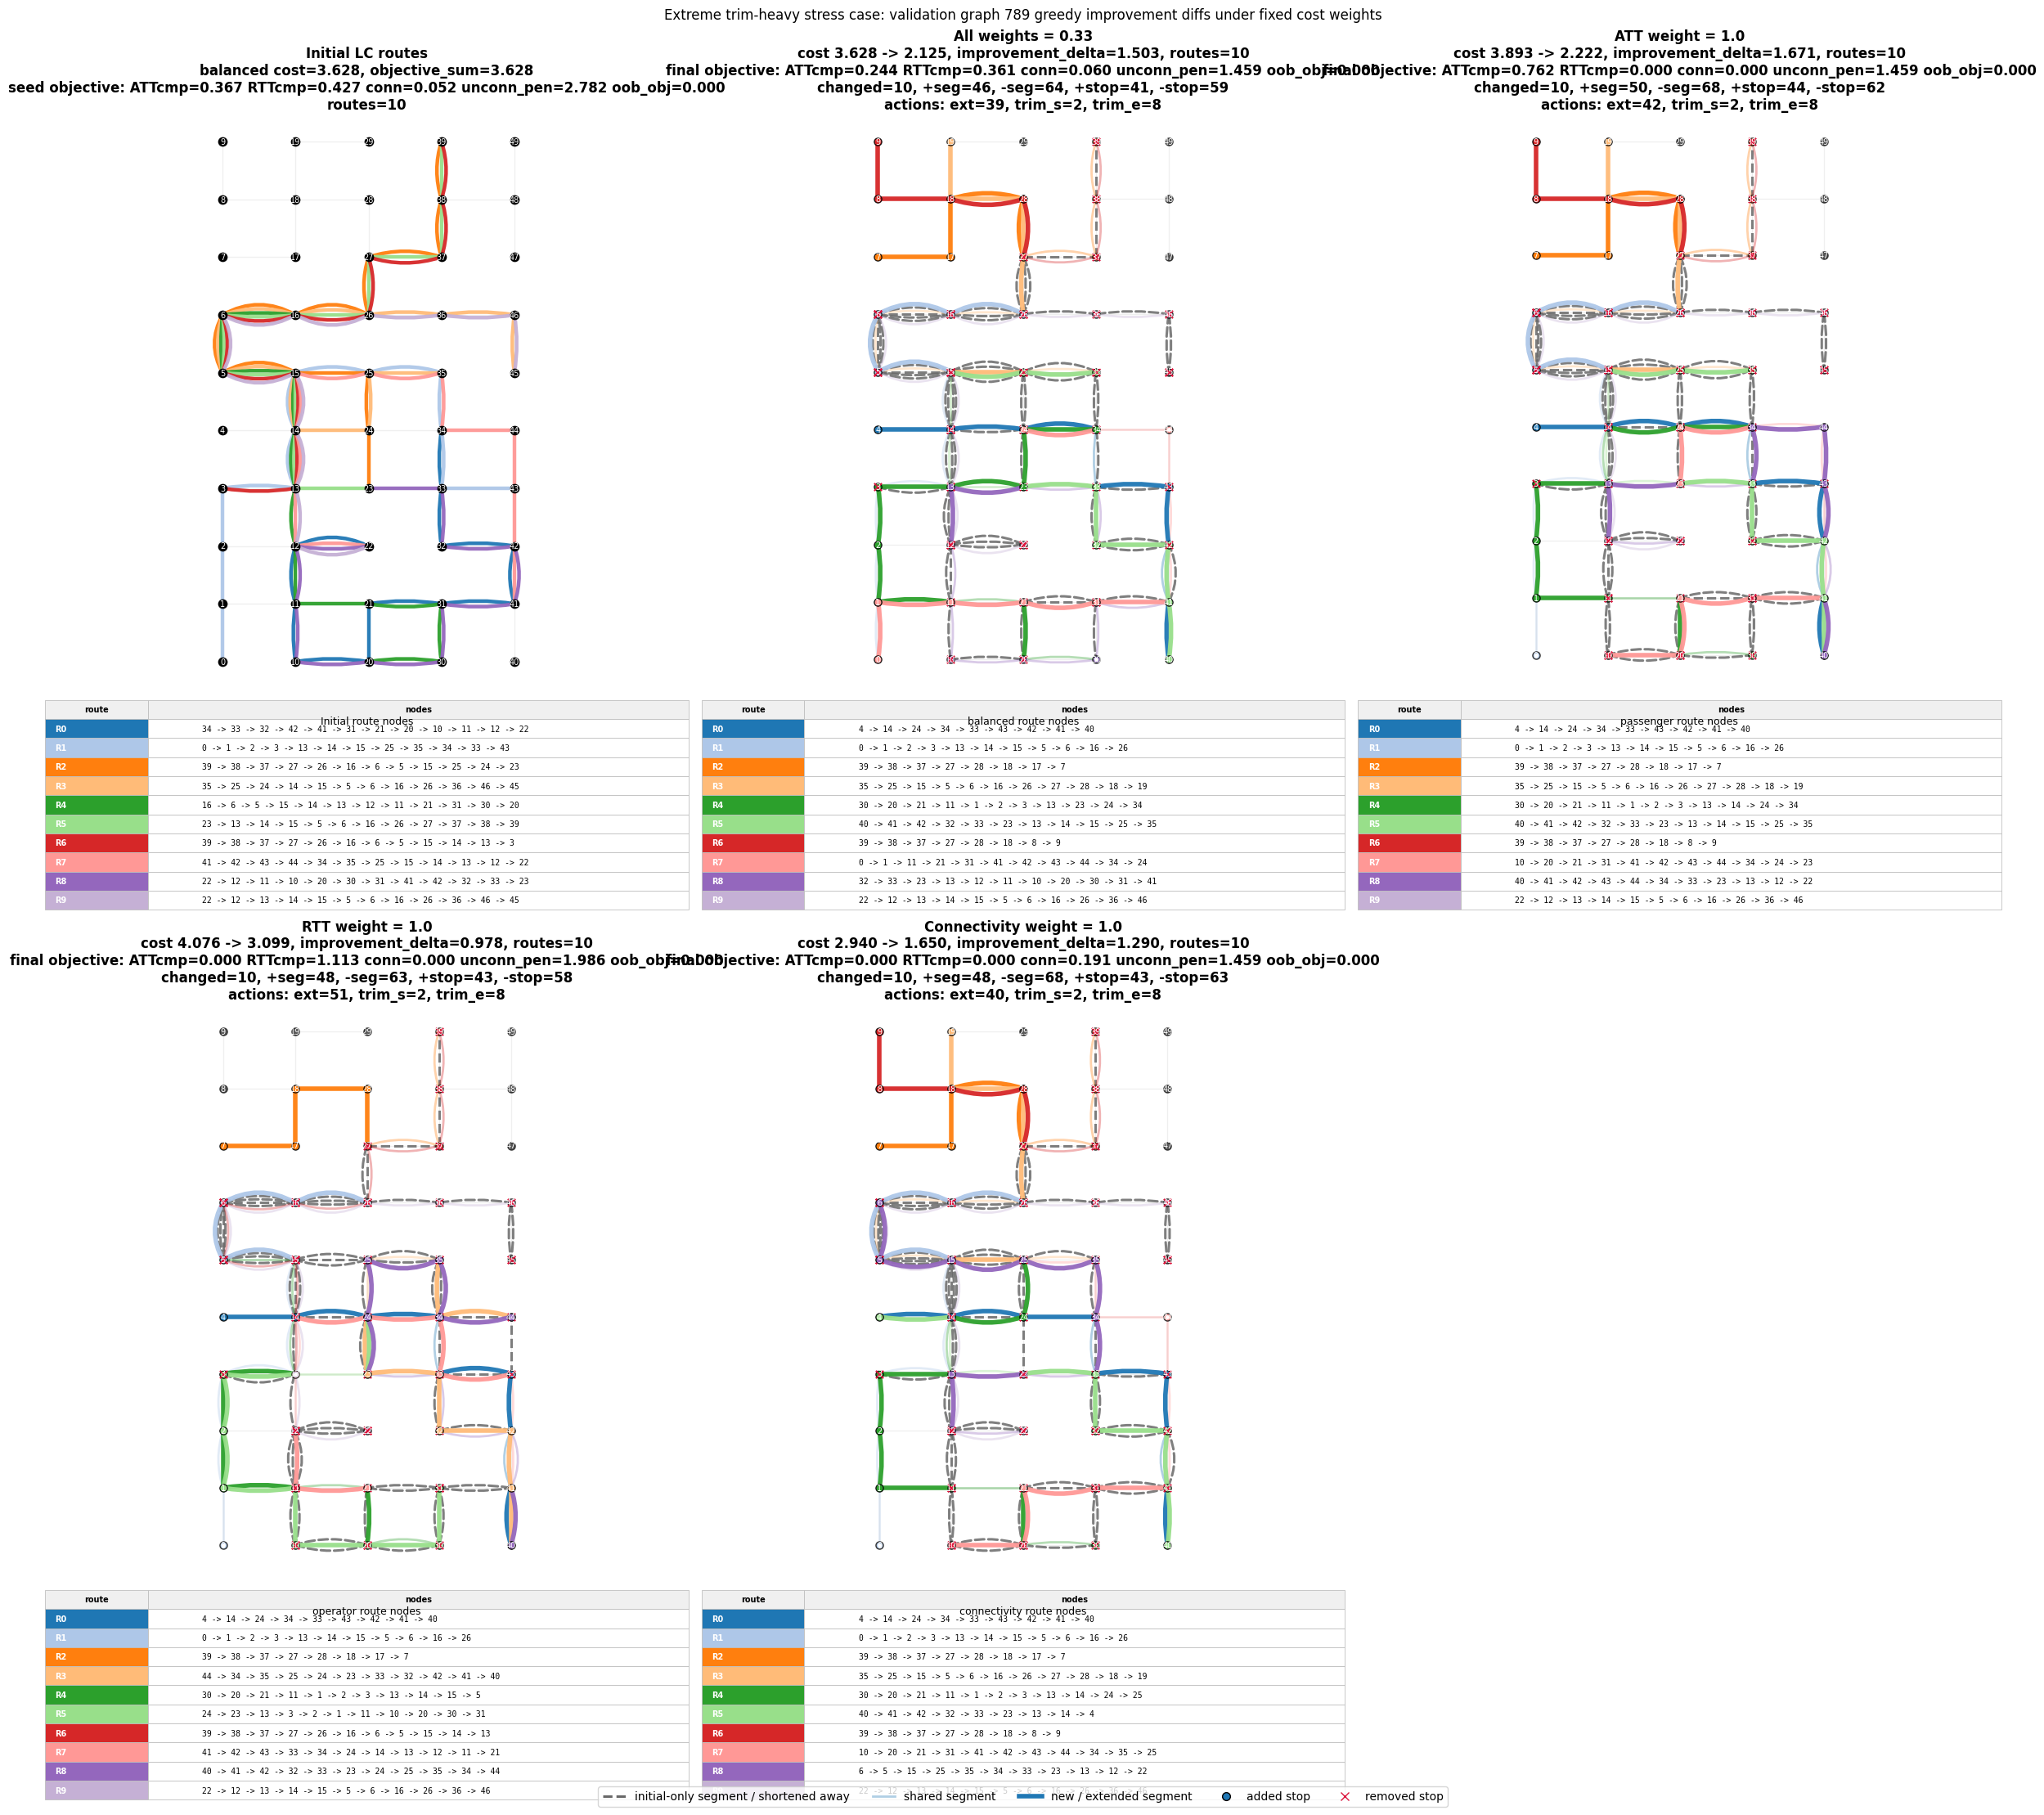

In [ ]:
extreme_case_results, extreme_case_table = render_lc_improvement_case(
    selected_case_graphs["extreme"],
    "Extreme trim-heavy stress case",
)


### 12B. Best positive improvement case


[case] Best positive improvement case: graph=687 scenarios=4


Best positive improvement case: validation graph 687


,scenario,demand_weight,route_weight,connectivity_weight,seed_cost,final_cost,improvement_delta,seed_ATT,final_ATT,seed_RTT,...,final_RTT_component,final_connectivity_component,final_uncovered_penalty,final_oob_penalty_objective,final_oob_penalty_diagnostic,extend,trim_start,trim_end,halt,avg_actions
0,balanced,0.33,0.33,0.33,3.953499,0.582239,3.371260,36.702011,40.252754,1235.356567,...,0.384846,0.057956,0.0,0.0,0.0,24,2,5,10,4.1
1,passenger,1.00,0.00,0.00,4.283595,0.422535,3.861060,36.702011,40.252754,1235.356567,...,0.000000,0.000000,0.0,0.0,0.0,24,2,5,10,4.1
2,operator,0.00,1.00,0.00,4.368190,1.166201,3.201989,36.702011,40.394119,1235.356567,...,1.166201,0.000000,0.0,0.0,0.0,24,2,5,10,4.1
3,connectivity,0.00,0.00,1.00,3.235442,0.175624,3.059818,36.702011,40.231503,1235.356567,...,0.000000,0.175624,0.0,0.0,0.0,24,2,5,10,4.1


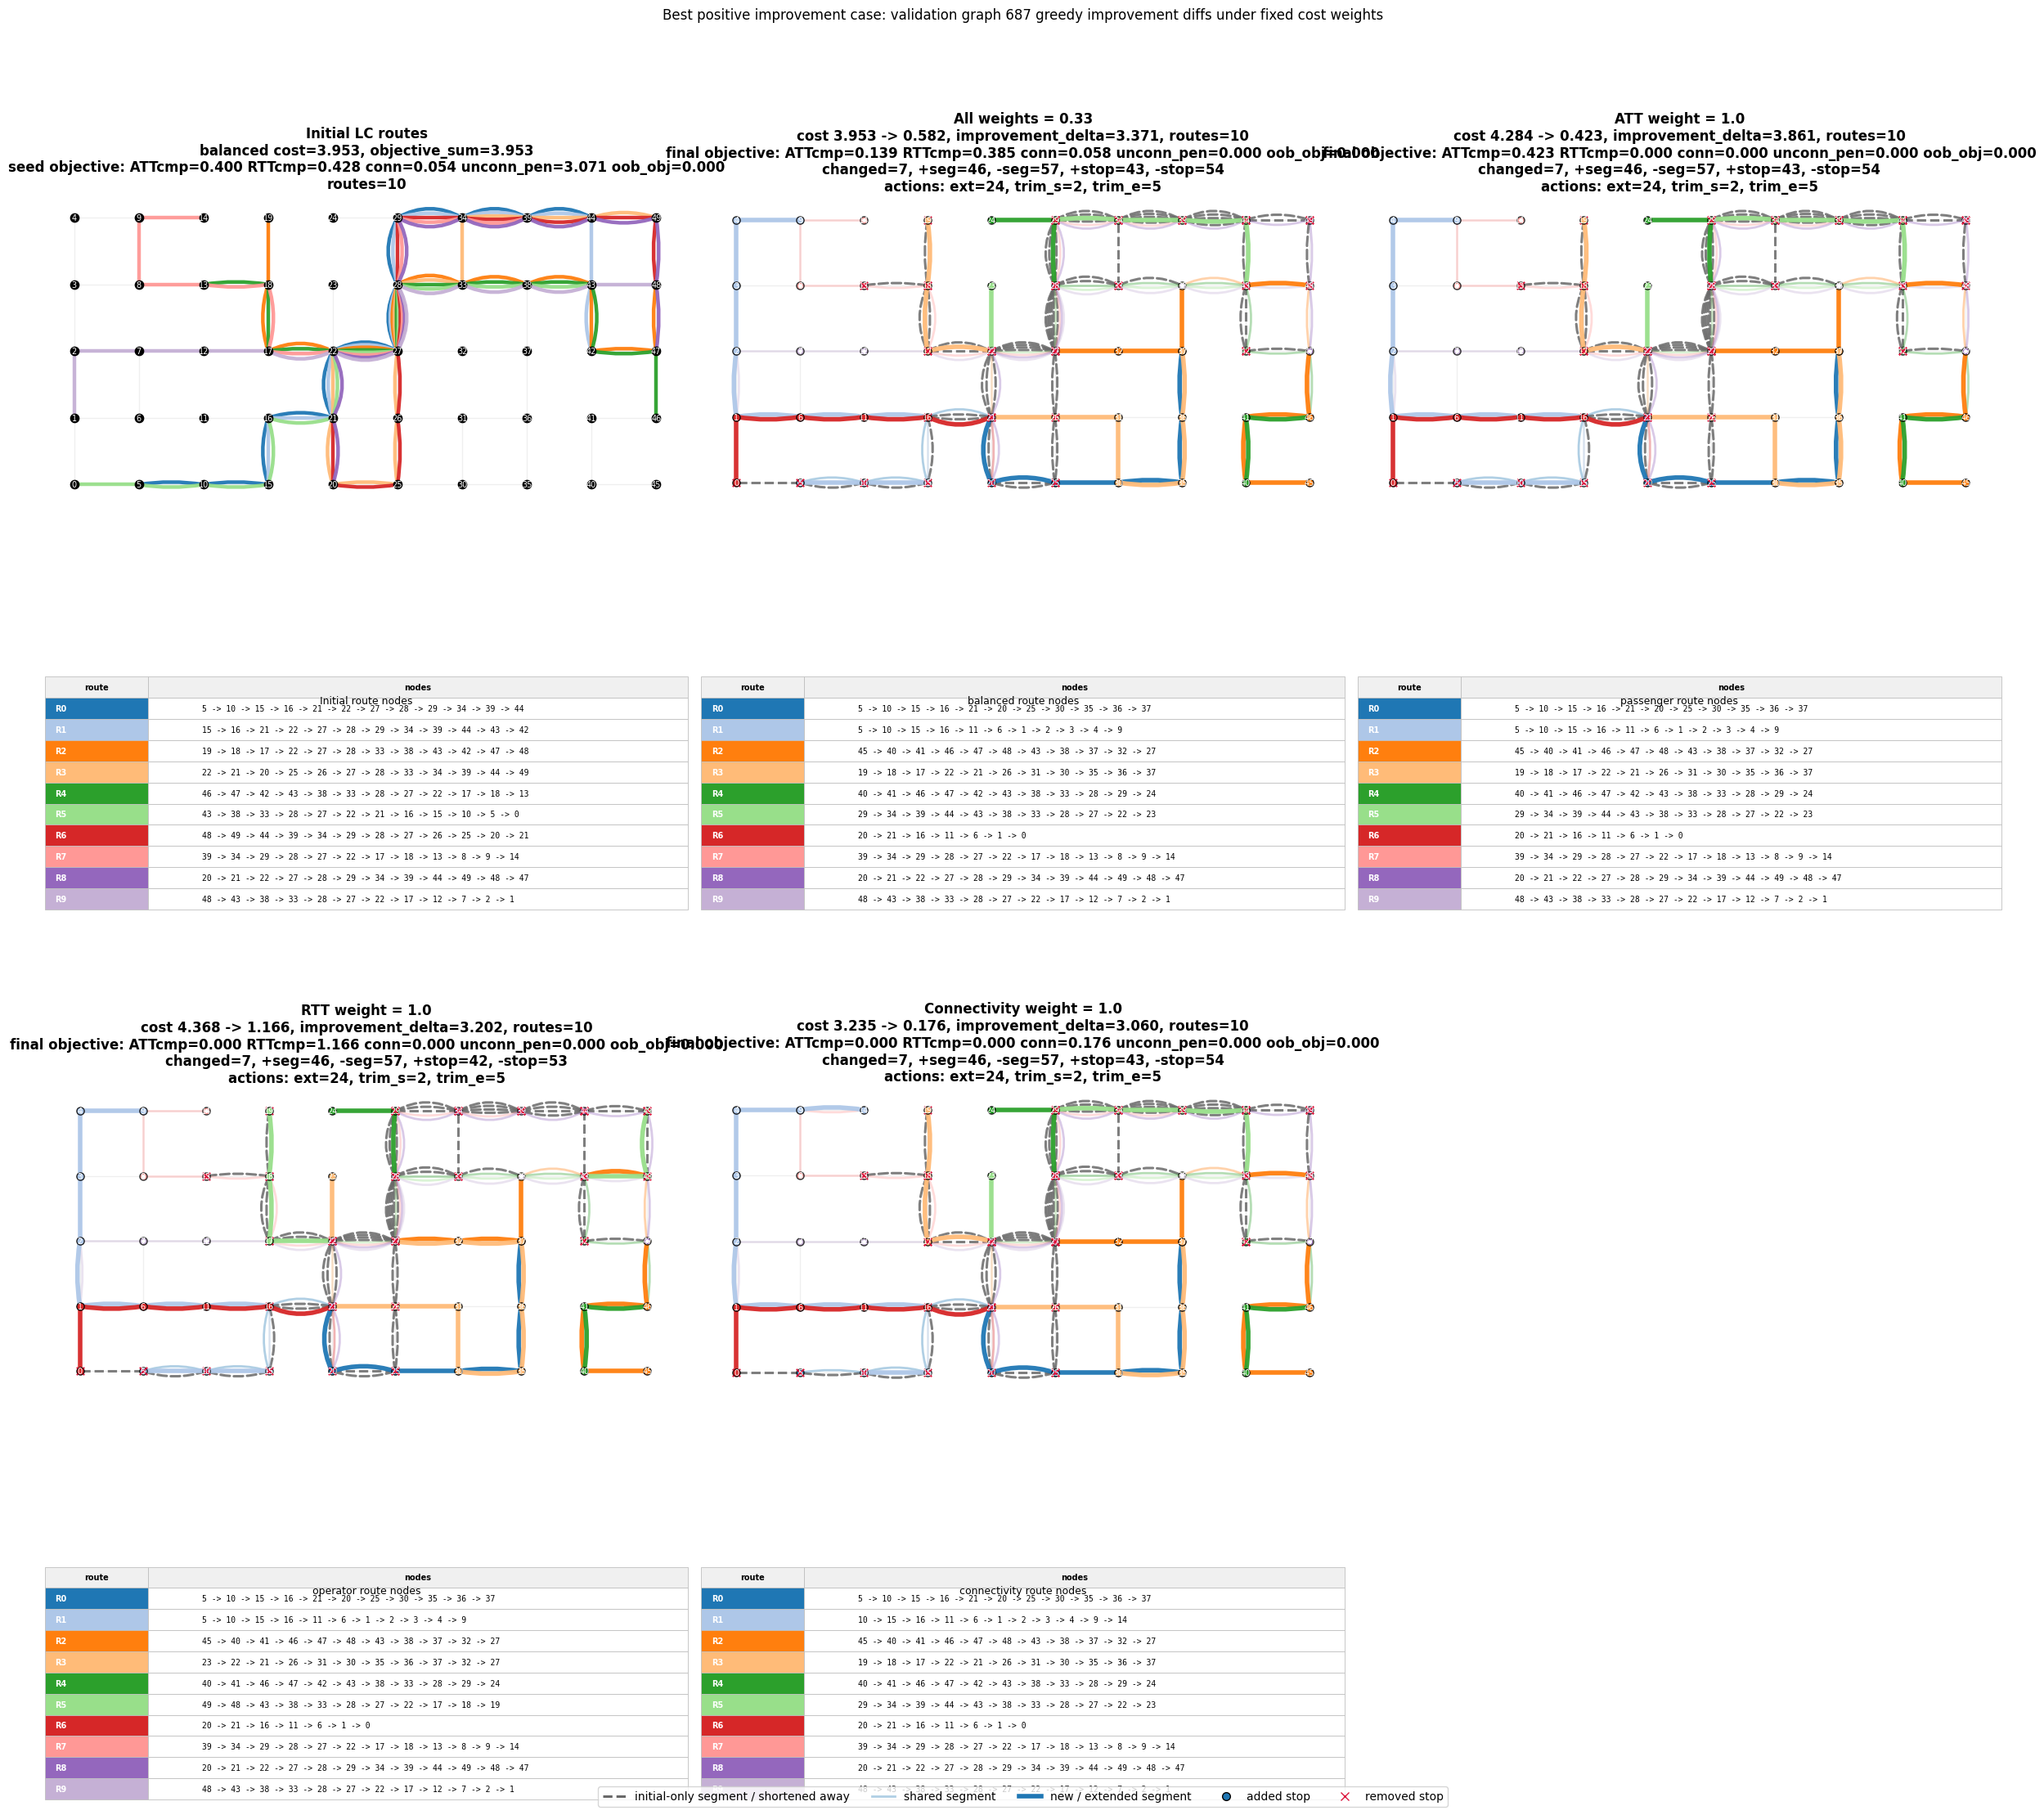

In [ ]:
best_case_results, best_case_table = render_lc_improvement_case(
    selected_case_graphs["best"],
    "Best positive improvement case",
)


### 12C. Median positive improvement case


[case] Median positive improvement case: graph=234 scenarios=4


Median positive improvement case: validation graph 234


,scenario,demand_weight,route_weight,connectivity_weight,seed_cost,final_cost,improvement_delta,seed_ATT,final_ATT,seed_RTT,...,final_RTT_component,final_connectivity_component,final_uncovered_penalty,final_oob_penalty_objective,final_oob_penalty_diagnostic,extend,trim_start,trim_end,halt,avg_actions
0,balanced,0.33,0.33,0.33,2.349731,0.733175,1.616556,34.854935,33.722473,1175.305908,...,0.506764,0.064034,0.0,0.0,0.0,31,3,6,10,5.0
1,passenger,1.00,0.00,0.00,2.245403,0.502274,1.743129,34.854935,34.423061,1175.305908,...,0.000000,0.000000,0.0,0.0,0.0,34,3,6,10,5.3
2,operator,0.00,1.00,0.00,3.174098,1.532487,1.641611,34.854935,34.530548,1175.305908,...,1.532487,0.000000,0.0,0.0,0.0,37,3,7,10,5.7
3,connectivity,0.00,0.00,1.00,1.656677,0.199735,1.456942,34.854935,34.186878,1175.305908,...,0.000000,0.199735,0.0,0.0,0.0,31,3,5,10,4.9


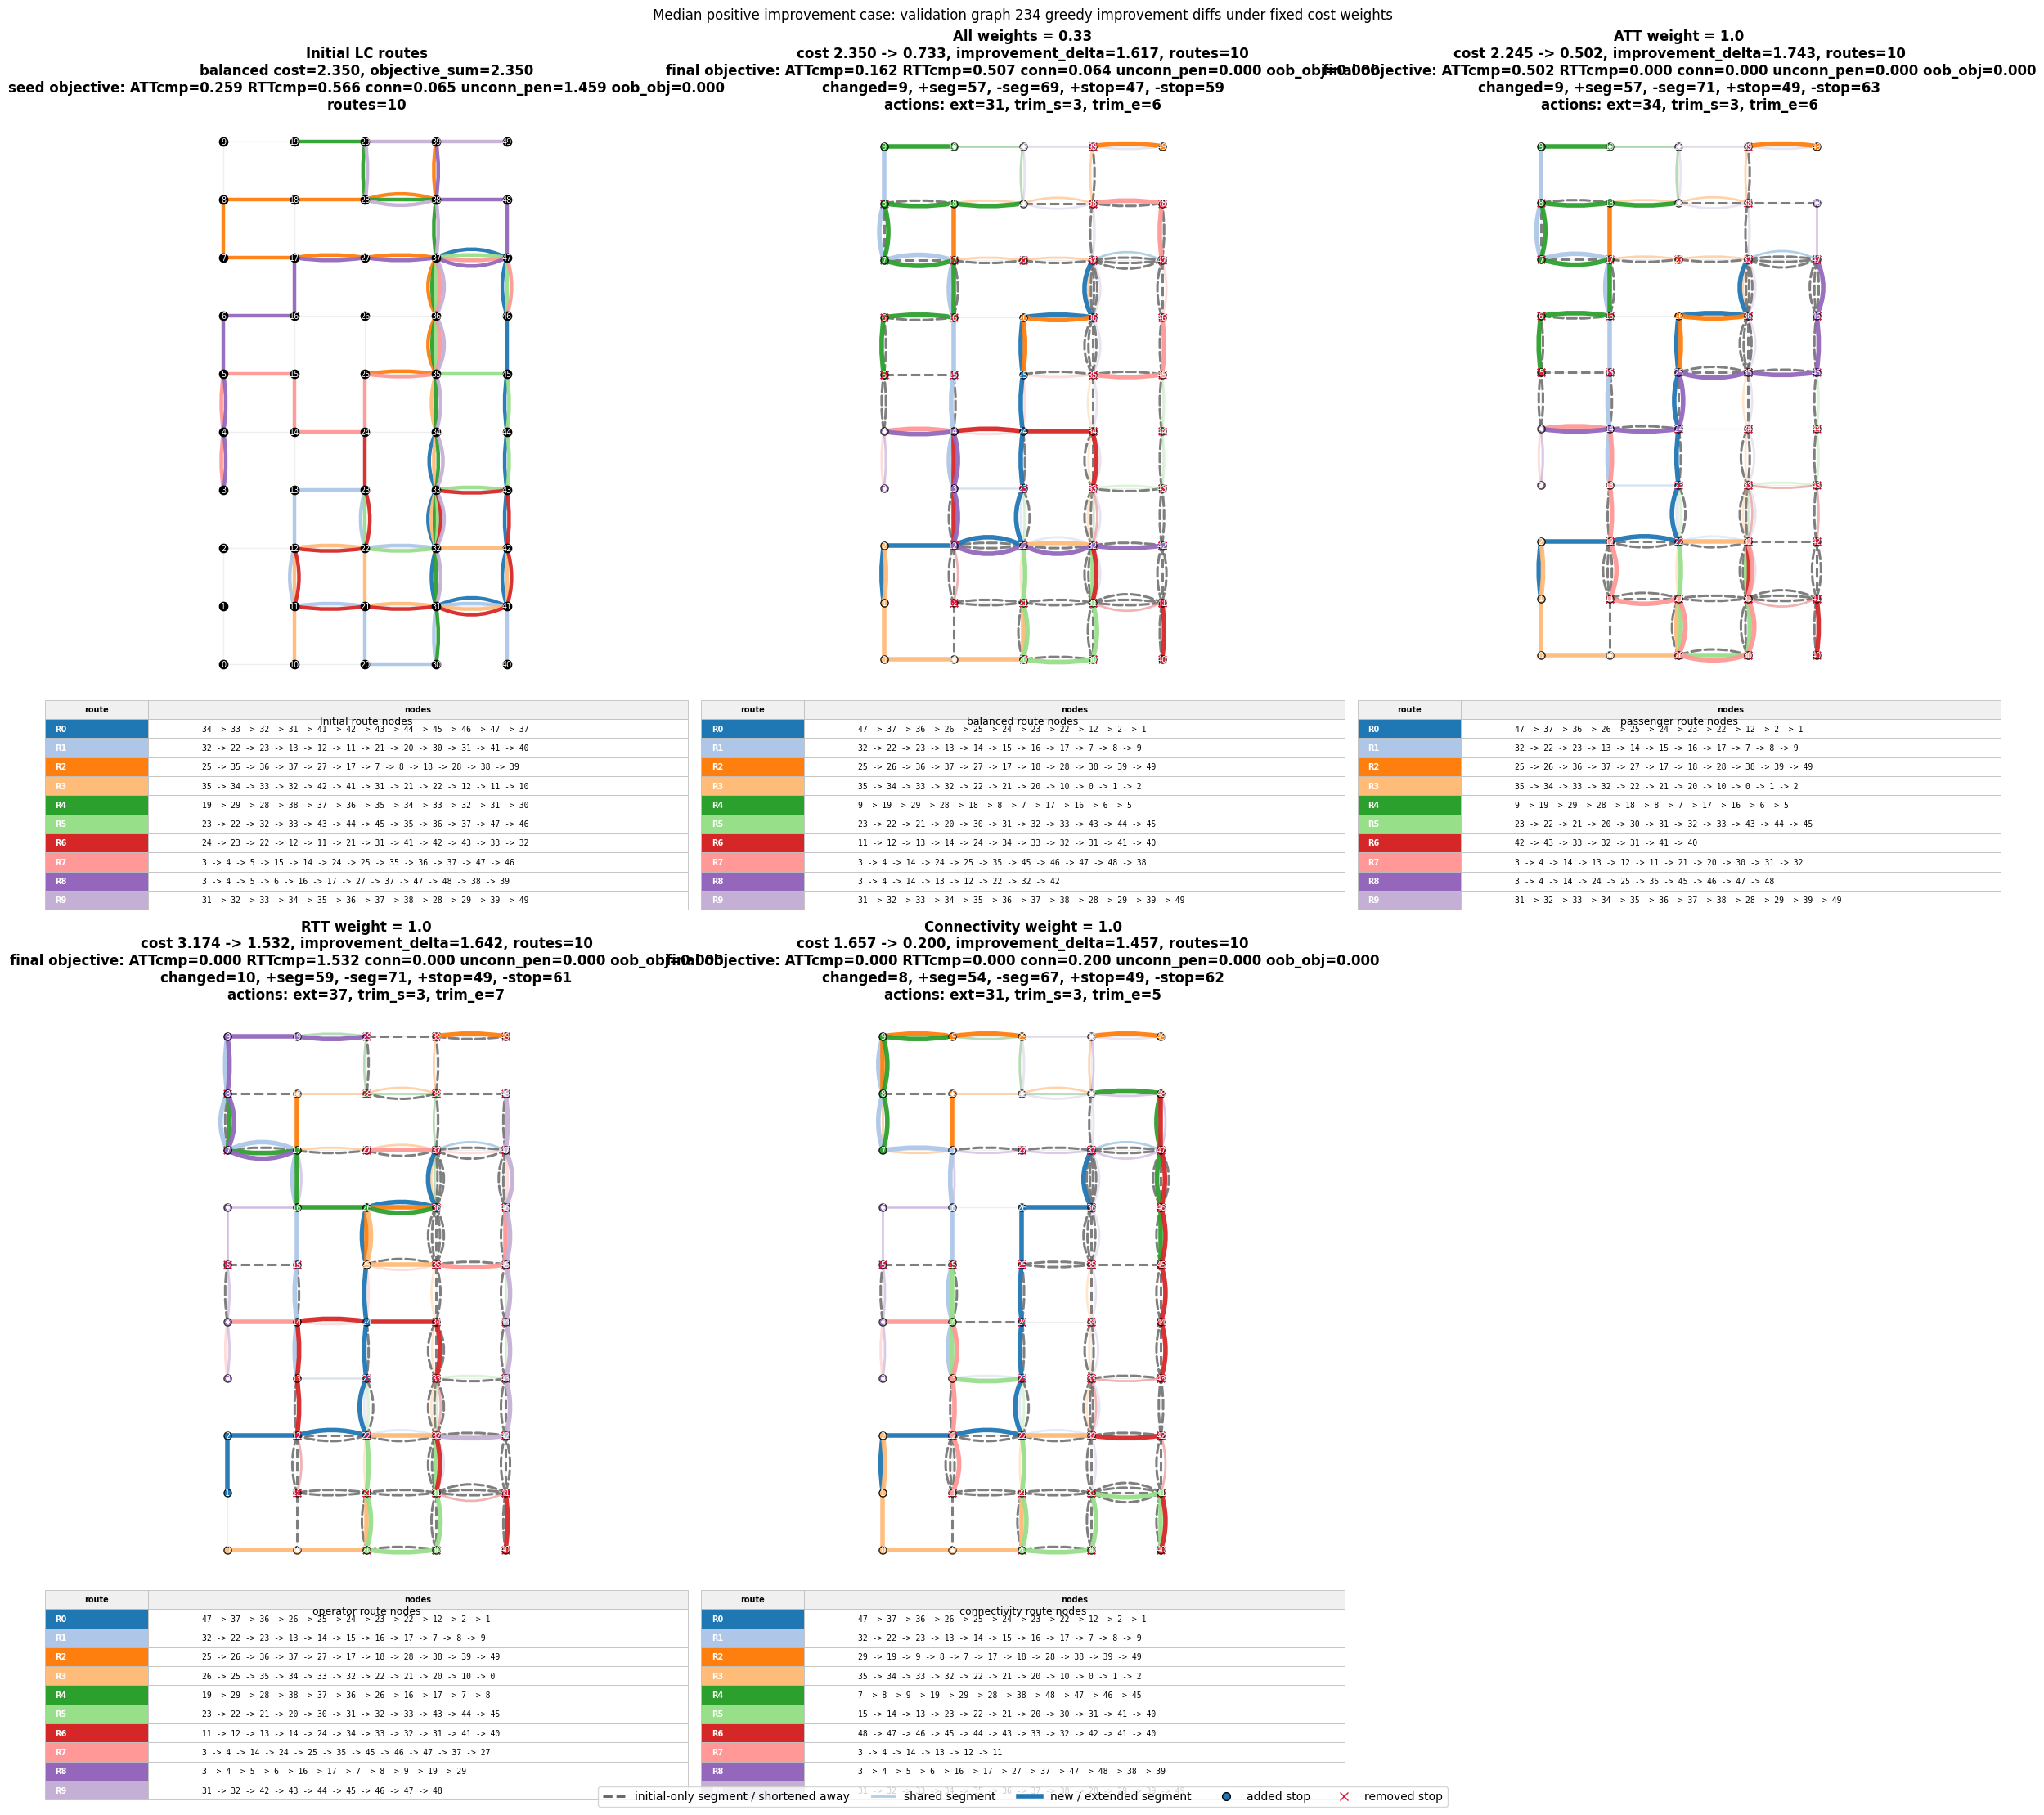

In [ ]:
median_case_results, median_case_table = render_lc_improvement_case(
    selected_case_graphs["median"],
    "Median positive improvement case",
)


## 15. Random Route Sanity Check


Graph: 744
Random seed cost:  6.2196
Improved cost:     0.6438
Delta:             5.5758
Action stats: {'extend_count': 32, 'trim_start_count': 2, 'trim_end_count': 5, 'halt_count': 10, 'total_count': 49, 'route_plan_count': 10, 'trim_count': 7, 'edit_count': 39, 'extend_rate': 0.6530612244897959, 'trim_start_rate': 0.04081632653061224, 'trim_end_rate': 0.10204081632653061, 'halt_rate': 0.20408163265306123, 'trim_rate': 0.14285714285714285, 'edit_rate': 0.7959183673469388, 'avg_actions_per_route': 4.9}


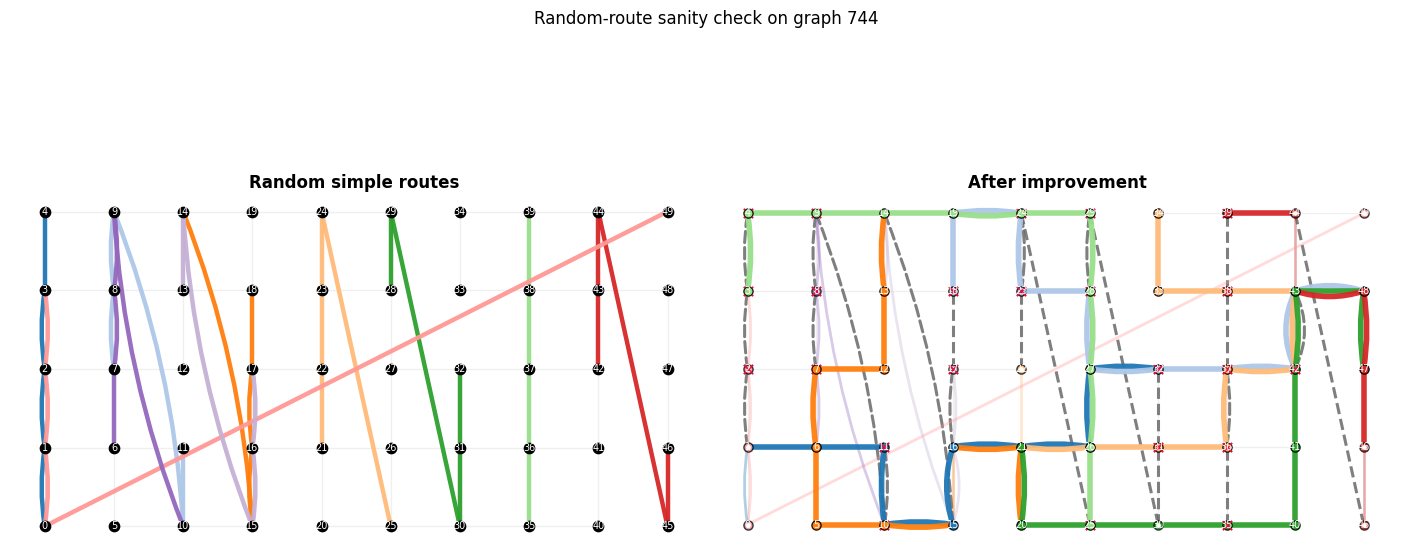

In [ ]:
import pandas as pd

from connectpt.routes_generator.torch_utils import get_batch_tensor_from_routes

RANDOM_ROUTE_GRAPH_POS = 0
RANDOM_ROUTE_LEN = 5
RANDOM_ROUTE_STRIDE = 7

random_graph_idx = int(VAL_INDICES[RANDOM_ROUTE_GRAPH_POS])
random_graph = graphs[random_graph_idx]
n_nodes = int(random_graph[STOP_KEY].num_nodes)
n_random_routes = int(TARGET_N_ROUTES or seed_routes.shape[1])

random_route_list = []
for route_idx in range(n_random_routes):
    start = (route_idx * RANDOM_ROUTE_STRIDE) % n_nodes
    route = [
        (start + offset) % n_nodes
        for offset in range(RANDOM_ROUTE_LEN)
    ]
    random_route_list.append(route)

random_seed_routes = get_batch_tensor_from_routes(
    [random_route_list],
    device,
)
random_graph_batch, _ = make_improvement_batch(
    graphs,
    seed_routes,
    torch.tensor([random_graph_idx], dtype=torch.long),
    device,
    training=False,
    target_n_routes=TARGET_N_ROUTES,
)

model.eval()
with torch.no_grad():
    random_state, random_seed_result, random_final_result, _, _, \
        random_actions, random_action_kinds = rollout_lc_improvement(
            model,
            cost_obj,
            random_graph_batch,
            random_seed_routes,
            MIN_ROUTE_LEN,
            MAX_ROUTE_LEN,
            greedy=True,
            cost_weights=cost_obj.get_weights(device),
            return_actions=True,
            force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
            max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
            max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
        )

random_improved_routes = get_batch_tensor_from_routes(
    random_state.routes,
    device,
)[0].detach().cpu()
random_initial_routes = random_seed_routes[0].detach().cpu()

print(f"Graph: {random_graph_idx}")
print(f"Random seed cost:  {random_seed_result.cost.item():.4f}")
print(f"Improved cost:     {random_final_result.cost.item():.4f}")
print(f"Delta:             {(random_seed_result.cost - random_final_result.cost).item():.4f}")
print("Action stats:", summarize_route_action_stats(random_actions, random_action_kinds))

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
plot_plain_route_set(
    axes[0],
    random_initial_routes,
    random_graph,
    "Random simple routes",
)
plot_route_diff(
    axes[1],
    random_improved_routes,
    random_initial_routes,
    random_graph,
    "After improvement",
)
fig.suptitle(f"Random-route sanity check on graph {random_graph_idx}")
plt.show()
